# LLM vs Classical ML for Intrusion Detection: Cross-Dataset & Adversarial Robustness Study

**Block-by-block execution, July 17 - Aug 25, 2026**

This notebook orchestrates the full pipeline:
- **Block 2** (TODAY): Dataset verification + schema lock
- **Block 3**: Classical baselines (Random Forest, XGBoost)
- **Block 4**: Fair evaluation harness
- **Block 5**: LLM arm (GPT-Neo-125M + QLoRA)
- **Block 6**: Cross-dataset experiment
- **Block 7**: Adversarial evasion crafting
- **Block 8**: Adversarial robustness testing
- **Block 9-13**: Results, figures, writing

Each block is self-contained. Run sequentially, save outputs as you go.

## SETUP — Run this first

Mounts Drive, installs dependencies, sets paths. Only needs to run once per Colab session.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Verify the dataset folder exists
import os
dataset_dir = '/content/drive/MyDrive/CybersecClassification'  # EDIT THIS if your folder is named differently
print("\nDatasets in drive:")
if os.path.exists(dataset_dir):
    for f in os.listdir(dataset_dir):
        size_gb = os.path.getsize(os.path.join(dataset_dir, f)) / 1024**3
        print(f"  {f:<50} {size_gb:>8.2f} GB")
else:
    print(f"  !! Folder not found at {dataset_dir}")
    print("     Edit the path above and rerun.")


Datasets in drive:
  NF-UNSW-NB15-V2.parquet                                0.05 GB
  NF-CSE-CIC-IDS2018-V2.parquet                          0.60 GB
  NF-UNSW-NB15-V2.parquet.zip                            0.05 GB
  NF-CSE-CIC-IDS2018-V2.parquet.zip                      0.50 GB
  ids_output                                             0.00 GB


In [ ]:
# Install and import dependencies
!pip install -q pandas scikit-learn xgboost pyarrow

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
import xgboost as xgb
import json
import pickle
from datetime import datetime

print("\nImports successful.")
print(f"Pandas:   {pd.__version__}")
print(f"XGBoost:  {xgb.__version__}")
print(f"scikit-learn:  {__import__('sklearn').__version__}")


Imports successful.
Pandas:   2.2.2
XGBoost:  3.3.0
scikit-learn:  1.6.1


In [ ]:
# Create output directories
output_base = '/content/drive/MyDrive/CybersecClassification/ids_output'
os.makedirs(output_base, exist_ok=True)
os.makedirs(f"{output_base}/models", exist_ok=True)
os.makedirs(f"{output_base}/results", exist_ok=True)
os.makedirs(f"{output_base}/figures", exist_ok=True)

print(f"Output directory: {output_base}")
print("  /models  — trained model files")
print("  /results — raw results JSON and CSVs")
print("  /figures — matplotlib PNGs, CSVs for paper")

Output directory: /content/drive/MyDrive/CybersecClassification/ids_output
  /models  — trained model files
  /results — raw results JSON and CSVs
  /figures — matplotlib PNGs, CSVs for paper


---

## BLOCK 2 — Dataset Verification

**Goal**: Confirm the two datasets share an identical schema, find label columns, check class balance.

**Expected output**: A report you paste into chat. We lock the feature list from that.

In [ ]:
# ============================================================
# BLOCK 2 CONFIG — EDIT THESE TWO PATHS
# ============================================================

DATASETS = {
    "NF-UNSW-NB15-v2": f"{dataset_dir}/NF-UNSW-NB15-V2.parquet",
    "NF-CSE-CIC-IDS2018-v2": f"{dataset_dir}/NF-CSE-CIC-IDS2018-V2.parquet",
}

SAMPLE_ROWS = 50_000          # rows read for dtype / preview inspection
FULL_LABEL_COUNT = True       # False = skip exact class counts (faster on 19M file)
CHUNK = 500_000               # chunk size for streaming reads

# If the filenames in your Drive are different, edit DATASETS above.
# For example, if you have "NF_UNSW_NB15_v2.csv" (underscores), change the paths.

In [ ]:
def read_head(path, nrows):
    """Read the first n rows regardless of csv or parquet."""
    if path.lower().endswith((".parquet", ".pq")):
        return pd.read_parquet(path).head(nrows)
    return pd.read_csv(path, nrows=nrows, low_memory=False)

def column_list(path):
    """Get column names without loading the data."""
    if path.lower().endswith((".parquet", ".pq")):
        import pyarrow.parquet as pq
        return list(pq.ParquetFile(path).schema.names)
    return list(pd.read_csv(path, nrows=0).columns)

def guess_label_columns(cols):
    """Find likely label columns without assuming exact names."""
    hits = []
    for c in cols:
        low = c.strip().lower()
        if low in ("label", "attack", "class", "category", "attack_cat", "type", "attack_type"):
            hits.append(c)
    return hits

def guess_bias_columns(cols):
    """Identifier fields that let a model memorise instead of learn."""
    hits = []
    for c in cols:
        low = c.strip().lower()
        if any(k in low for k in ("addr", "ip_src", "ip_dst", "src_ip", "dst_ip",
                                  "port", "timestamp", "time", "uid", "flow_id", "id")):
            hits.append(c)
    return hits

def count_values_streamed(path, col):
    """Exact value counts for one column, streamed in chunks."""
    if path.lower().endswith((".parquet", ".pq")):
        return pd.read_parquet(path, columns=[col])[col].value_counts()
    total = None
    for chunk in pd.read_csv(path, usecols=[col], chunksize=CHUNK, low_memory=False):
        vc = chunk[col].value_counts()
        total = vc if total is None else total.add(vc, fill_value=0)
    return total.astype(int).sort_values(ascending=False)

print("Helper functions loaded.")

Helper functions loaded.


In [ ]:
print("=" * 72)
print("BLOCK 2 - DATASET VERIFICATION REPORT")
print("=" * 72)

schemas = {}

for name, path in DATASETS.items():
    print(f"\n\n########## {name} ##########")

    if not os.path.exists(path):
        print(f"  !! FILE NOT FOUND at {path}")
        print("     Fix the path in CONFIG and rerun.")
        continue

    size_gb = os.path.getsize(path) / 1024**3
    print(f"  file size            {size_gb:.2f} GB")

    cols = column_list(path)
    schemas[name] = cols
    print(f"  column count         {len(cols)}")

    df = read_head(path, SAMPLE_ROWS)

    print("\n  --- COLUMNS AND DTYPES (from sample) ---")
    for i, c in enumerate(cols, 1):
        dt = df[c].dtype if c in df.columns else "?"
        print(f"    {i:>3}. {c:<30} {dt}")

    labels = guess_label_columns(cols)
    bias = guess_bias_columns(cols)

    print(f"\n  --- LIKELY LABEL COLUMNS ---   {labels if labels else 'NONE FOUND - inspect manually'}")
    print(f"  --- LIKELY BIAS-PRONE COLUMNS (drop these) ---")
    for b in bias:
        print(f"        {b}")

    for lab in labels:
        print(f"\n  --- VALUE COUNTS for '{lab}' ---")
        try:
            if FULL_LABEL_COUNT:
                vc = count_values_streamed(path, lab)
                total = int(vc.sum())
                print(f"    total rows: {total:,}")
                for k, v in vc.items():
                    print(f"      {str(k):<28} {int(v):>12,}   {100*v/total:6.2f}%")
            else:
                vc = df[lab].value_counts()
                print(f"    (sample of {len(df):,} rows only)")
                for k, v in vc.items():
                    print(f"      {str(k):<28} {int(v):>12,}   {100*v/len(df):6.2f}%")
        except Exception as e:
            print(f"    could not count: {e}")

    print("\n  --- FIRST 3 ROWS ---")
    with pd.option_context("display.max_columns", None, "display.width", 200):
        print(df.head(3).to_string())

BLOCK 2 - DATASET VERIFICATION REPORT


########## NF-UNSW-NB15-v2 ##########
  file size            0.05 GB
  column count         43

  --- COLUMNS AND DTYPES (from sample) ---
      1. L4_SRC_PORT                    int32
      2. L4_DST_PORT                    int32
      3. PROTOCOL                       int16
      4. L7_PROTO                       float32
      5. IN_BYTES                       int32
      6. IN_PKTS                        int16
      7. OUT_BYTES                      int32
      8. OUT_PKTS                       int16
      9. TCP_FLAGS                      int8
     10. CLIENT_TCP_FLAGS               int8
     11. SERVER_TCP_FLAGS               int8
     12. FLOW_DURATION_MILLISECONDS     int32
     13. DURATION_IN                    int16
     14. DURATION_OUT                   int16
     15. MIN_TTL                        int16
     16. MAX_TTL                        int16
     17. LONGEST_FLOW_PKT               int16
     18. SHORTEST_FLOW_PKT              

In [ ]:
# ============================================================
# SCHEMA COMPATIBILITY CHECK
# ============================================================

print("\n\n" + "=" * 72)
print("SCHEMA COMPATIBILITY CHECK")
print("=" * 72)

if len(schemas) < 2:
    print("Need both datasets loaded to compare. Fix paths above.")
else:
    names = list(schemas.keys())
    a, b = names[0], names[1]
    sa, sb = set(schemas[a]), set(schemas[b])

    print(f"\n  {a}:  {len(sa)} columns")
    print(f"  {b}:  {len(sb)} columns")
    print(f"  shared columns:      {len(sa & sb)}")

    only_a = sa - sb
    only_b = sb - sa

    if not only_a and not only_b:
        print("\n  >>> IDENTICAL COLUMN SETS. Cross-dataset transfer is viable. <<<")
        if schemas[a] == schemas[b]:
            print("      Column ORDER also matches.")
        else:
            print("      NOTE: same columns, different ORDER. Reorder before training.")
    else:
        print("\n  >>> SCHEMAS DIFFER. Use only the shared columns. <<<")
        if only_a:
            print(f"\n  only in {a}:")
            for c in sorted(only_a):
                print(f"      {c}")
        if only_b:
            print(f"\n  only in {b}:")
            for c in sorted(only_b):
                print(f"      {c}")

    # Proposed feature set
    labels_all = set()
    bias_all = set()
    for n in names:
        labels_all |= set(guess_label_columns(schemas[n]))
        bias_all |= set(guess_bias_columns(schemas[n]))

    features = [c for c in schemas[a] if c in sb and c not in labels_all and c not in bias_all]

    print("\n" + "=" * 72)
    print(f"PROPOSED FEATURE SET  ({len(features)} features)")
    print("=" * 72)
    for i, c in enumerate(features, 1):
        print(f"  {i:>3}. {c}")
    print("\n  DROPPED as label:      ", sorted(labels_all))
    print("  DROPPED as bias-prone: ", sorted(bias_all))
    print("\n  Sanity check this list by hand before trusting it.")

print("\n" + "=" * 72)
print("DONE — copy-paste this entire report into the chat")
print("=" * 72)



SCHEMA COMPATIBILITY CHECK

  NF-UNSW-NB15-v2:  43 columns
  NF-CSE-CIC-IDS2018-v2:  43 columns
  shared columns:      43

  >>> IDENTICAL COLUMN SETS. Cross-dataset transfer is viable. <<<
      Column ORDER also matches.

PROPOSED FEATURE SET  (38 features)
    1. PROTOCOL
    2. L7_PROTO
    3. IN_BYTES
    4. IN_PKTS
    5. OUT_BYTES
    6. OUT_PKTS
    7. TCP_FLAGS
    8. CLIENT_TCP_FLAGS
    9. SERVER_TCP_FLAGS
   10. FLOW_DURATION_MILLISECONDS
   11. DURATION_IN
   12. DURATION_OUT
   13. MIN_TTL
   14. MAX_TTL
   15. LONGEST_FLOW_PKT
   16. SHORTEST_FLOW_PKT
   17. MIN_IP_PKT_LEN
   18. MAX_IP_PKT_LEN
   19. SRC_TO_DST_SECOND_BYTES
   20. DST_TO_SRC_SECOND_BYTES
   21. RETRANSMITTED_IN_BYTES
   22. RETRANSMITTED_IN_PKTS
   23. RETRANSMITTED_OUT_BYTES
   24. RETRANSMITTED_OUT_PKTS
   25. SRC_TO_DST_AVG_THROUGHPUT
   26. DST_TO_SRC_AVG_THROUGHPUT
   27. NUM_PKTS_UP_TO_128_BYTES
   28. NUM_PKTS_128_TO_256_BYTES
   29. NUM_PKTS_256_TO_512_BYTES
   30. NUM_PKTS_512_TO_1024_BYTES
 

---

## BLOCK 3 — Classical Baselines [NOT YET STARTED]

Once schema is locked:
1. Load both datasets with the locked feature set
2. Train Random Forest and XGBoost on UNSW-NB15 same-dataset
3. Reproduce the famous high scores (baseline validation)
4. Save trained models

**Timeline**: July 21-24

In [ ]:
# ============================================================
# BLOCK 3 — Classical Baselines (same-dataset)
# Order matters: config, then imports, then functions, then run.
# ============================================================

import os
import joblib
import pandas as pd
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import xgboost as xgb

# ---------- PATHS ----------
dataset_dir = '/content/drive/MyDrive/CybersecClassification'
OUTPUT      = '/content/drive/MyDrive/CybersecClassification/ids_output'

os.makedirs(f"{OUTPUT}/models",  exist_ok=True)
os.makedirs(f"{OUTPUT}/results", exist_ok=True)
os.makedirs(f"{OUTPUT}/figures", exist_ok=True)

UNSW = f"{dataset_dir}/NF-UNSW-NB15-V2.parquet"
CIC  = f"{dataset_dir}/NF-CSE-CIC-IDS2018-V2.parquet"

UNSW_BALANCED  = f"{OUTPUT}/unsw_balanced_50k.parquet"
RF_MODEL       = f"{OUTPUT}/models/rf_baseline.joblib"
XGB_MODEL      = f"{OUTPUT}/models/xgb_baseline.joblib"
BLOCK3_RESULTS = f"{OUTPUT}/results/block3_baselines.csv"

# ---------- LOCKED CONFIG (from Block 2, 24 July) ----------
FEATURES = [
    'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
    'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
    'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES',
    'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
    'ICMP_TYPE', 'ICMP_IPV4_TYPE',
    'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE',
]

LABEL         = 'Label'
DROPPED_BIAS  = ['L4_SRC_PORT', 'L4_DST_PORT', 'DNS_QUERY_ID']
DROPPED_LABEL = ['Attack']      # taxonomies differ across datasets, unusable
N_PER_CLASS   = 50_000
SEEDS         = [42, 43, 44, 45]

print(f"{len(FEATURES)} features locked, binary target '{LABEL}'")


# ---------- FUNCTIONS ----------
def load_balanced(path, n_per_class, seed=42, batch_size=1_000_000):
    """Stream a parquet file and return a class-balanced sample."""
    cols = FEATURES + [LABEL]
    pf = pq.ParquetFile(path)
    total_rows = pf.metadata.num_rows

    # Keep every attack row (scarce). Subsample benign (abundant).
    keep_frac = min(1.0, (n_per_class * 8) / total_rows)

    ben_parts, att_parts = [], []
    for batch in pf.iter_batches(batch_size=batch_size, columns=cols):
        b = batch.to_pandas()
        att_parts.append(b[b[LABEL] == 1])
        ben = b[b[LABEL] == 0]
        if keep_frac < 1.0:
            ben = ben.sample(frac=keep_frac, random_state=seed)
        ben_parts.append(ben)

    benign = pd.concat(ben_parts, ignore_index=True)
    attack = pd.concat(att_parts, ignore_index=True)

    n = min(n_per_class, len(benign), len(attack))
    if n < n_per_class:
        print(f"  ! only {n:,} per class available (wanted {n_per_class:,})")

    benign = benign.sample(n=n, random_state=seed)
    attack = attack.sample(n=n, random_state=seed)

    df = pd.concat([benign, attack], ignore_index=True)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    df[FEATURES] = df[FEATURES].astype('float32')
    return df


def evaluate(model, X, y, name=""):
    """One metric definition used by every model, everywhere."""
    pred = model.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        'model': name,
        'f1':        f1_score(y, pred),
        'precision': precision_score(y, pred),
        'recall':    recall_score(y, pred),
        'fpr':       fp / (fp + tn),   # false alarms
        'fnr':       fn / (fn + tp),   # missed attacks — the costly error
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }


# ---------- LOAD (cached) ----------
if os.path.exists(UNSW_BALANCED):
    print(f"\nLoading cached balanced data...")
    df = pd.read_parquet(UNSW_BALANCED)
else:
    print(f"\nComputing balanced sample (first run only)...")
    df = load_balanced(UNSW, N_PER_CLASS, seed=42)
    df.to_parquet(UNSW_BALANCED, index=False)
    print(f"  saved to {UNSW_BALANCED}")

print(f"  {len(df):,} rows, {df[LABEL].mean():.1%} attack")


# ---------- SPLIT ----------
X_tr, X_te, y_tr, y_te = train_test_split(
    df[FEATURES], df[LABEL],
    test_size=0.3, random_state=42, stratify=df[LABEL]
)
print(f"  train {len(X_tr):,} | test {len(X_te):,}")


# ---------- TRAIN (cached) ----------
if os.path.exists(RF_MODEL) and os.path.exists(XGB_MODEL):
    print("\nLoading cached models...")
    rf = joblib.load(RF_MODEL)
    xg = joblib.load(XGB_MODEL)
else:
    print("\nTraining (first run only)...")
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    print("  RandomForest done")

    xg = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                           eval_metric='logloss')
    xg.fit(X_tr, y_tr)
    print("  XGBoost done")

    joblib.dump(rf, RF_MODEL)
    joblib.dump(xg, XGB_MODEL)
    print(f"  models saved to {OUTPUT}/models/")


# ---------- EVALUATE AND SAVE ----------
results = [
    evaluate(rf, X_te, y_te, "RandomForest"),
    evaluate(xg, X_te, y_te, "XGBoost"),
]

results_df = pd.DataFrame(results).round(4)
results_df.to_csv(BLOCK3_RESULTS, index=False)
print(f"\nresults saved to {BLOCK3_RESULTS}\n")

results_df

38 features locked, binary target 'Label'

Loading cached balanced data...
  100,000 rows, 50.0% attack
  train 70,000 | test 30,000

Loading cached models...


In [ ]:
# ============================================================
# BLOCK 3.5 — Leakage audit
# Too-good scores are guilty until proven innocent.
# ============================================================
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# --- Check 1: feature importance from XGBoost ---
imp = pd.DataFrame({
    'feature': FEATURES,
    'importance': xg.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 10 features XGBoost relies on:")
print(imp.head(10).to_string(index=False))
print(f"\nTop feature alone = {imp.iloc[0]['importance']:.1%} of total importance")
print(f"Top 3 together    = {imp.head(3)['importance'].sum():.1%}")

# --- Check 2: how predictive is each feature ALONE? ---
# A single one-level decision stump per feature. If any hits ~0.95,
# that feature nearly equals the label and deserves suspicion.
print("\nSingle-feature F1 (stump on each feature alone):")
solo = []
for f in FEATURES:
    stump = DecisionTreeClassifier(max_depth=1, random_state=42)
    stump.fit(X_tr[[f]], y_tr)
    solo.append((f, f1_score(y_te, stump.predict(X_te[[f]]))))

solo_df = pd.DataFrame(solo, columns=['feature', 'solo_f1']).sort_values(
    'solo_f1', ascending=False).reset_index(drop=True)
print(solo_df.head(10).to_string(index=False))

print("\n--- READING THIS ---")
print("Top XGBoost feature > ~60% of importance  -> investigate that feature")
print("Any single-feature F1 > ~0.90             -> likely leak, tell Claude")
print("Importance spread out + solo F1s modest   -> UNSW is just easy, we're fine")

In [ ]:
# ============================================================
# BLOCK 3.6 — Iterative leakage audit
# Remove artifact features one layer at a time until no single
# feature can stand in for the label. Every drop is a decision
# YOU make from the evidence, not an automatic deletion.
# ============================================================
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

def audit(features, X_tr, X_te, y_tr, y_te, top_n=12):
    """
    For a given feature set, report two things:
      1. Solo F1 — how well each feature predicts the label ALONE
         (a one-question stump). High = artifact suspicion.
      2. Full-model F1 + importance concentration — how good the
         whole model is and whether it leans on one crutch.
    """
    # 1. Solo F1 per feature
    solo = []
    for f in features:
        stump = DecisionTreeClassifier(max_depth=1, random_state=42)
        stump.fit(X_tr[[f]], y_tr)
        solo.append((f, f1_score(y_te, stump.predict(X_te[[f]]))))
    solo_df = (pd.DataFrame(solo, columns=['feature', 'solo_f1'])
               .sort_values('solo_f1', ascending=False)
               .reset_index(drop=True))

    # 2. Full model on this feature set
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr[features], y_tr)
    full_f1 = f1_score(y_te, rf.predict(X_te[features]))
    imp = (pd.DataFrame({'feature': features,
                         'importance': rf.feature_importances_})
           .sort_values('importance', ascending=False)
           .reset_index(drop=True))

    print(f"  Full-model F1 on {len(features)} features: {full_f1:.4f}")
    print(f"  Top feature carries {imp.iloc[0]['importance']:.1%} of importance "
          f"({imp.iloc[0]['feature']})")
    print(f"\n  Highest solo-F1 features (artifact suspects):")
    print(solo_df.head(top_n).to_string(index=False))
    return solo_df, imp, full_f1


# ---- ROUND 1: the full 38 features, as they stand now ----
print("="*60)
print("ROUND 1 — all 38 features")
print("="*60)
solo_df, imp, full_f1 = audit(FEATURES, X_tr, X_te, y_tr, y_te)

print("\n\n>>> Features with solo F1 > 0.90 (prime suspects):")
suspects = solo_df[solo_df['solo_f1'] > 0.90]['feature'].tolist()
print("   ", suspects)
print("\nDon't delete blindly. Read the list, then tell Claude which to drop.")
print("Rule of thumb: TTL and fixed packet-SIZE features are artifacts.")
print("Flag/count/throughput BEHAVIOUR features are usually real signal.")

In [ ]:
# ============================================================
# BLOCK 3.6b — Test-drop a layer and re-audit
# Edit TO_DROP, run, read the result, decide the next layer.
# ============================================================

# --- EDIT THIS LIST as you decide, based on the audit above ---
TO_DROP = [
    'MIN_TTL', 'MAX_TTL',          # environmental leak — OS/hop fingerprint
    'MIN_IP_PKT_LEN',            # uncomment to test dropping the next layer
    'MAX_IP_PKT_LEN',
    'SERVER_TCP_FLAGS'
]

remaining = [f for f in FEATURES if f not in TO_DROP]

print("="*60)
print(f"RE-AUDIT after dropping {len(TO_DROP)}: {TO_DROP}")
print(f"{len(remaining)} features remain")
print("="*60)
solo_df2, imp2, full_f1_2 = audit(remaining, X_tr, X_te, y_tr, y_te)

print("\n>>> Still above 0.90 solo F1:")
still = solo_df2[solo_df2['solo_f1'] > 0.90]['feature'].tolist()
print("   ", still if still else "NONE — no single feature stands in for the label")

print(f"\nFull-model F1 moved: {full_f1:.4f} (all) -> {full_f1_2:.4f} (pruned)")
print("Small drop = you removed crutches, real signal remains. GOOD.")
print("Huge drop  = you may have cut real signal. Reconsider.")

In [ ]:
# ============================================================
# BLOCK 3.7 — First real cross-dataset test + feature ablation
# Question: which features are ARTIFACT (don't transfer) vs
# SIGNAL (do transfer)? We stop guessing and let CIC decide.
# ============================================================
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import f1_score, confusion_matrix

# ---- Load a balanced CIC sample (first time touching CIC) ----
# Reuses load_balanced from Block 3 — same function, different path.
CIC_BALANCED = f"{OUTPUT}/cic_balanced_50k.parquet"

if os.path.exists(CIC_BALANCED):
    print("Loading cached CIC sample...")
    df_cic = pd.read_parquet(CIC_BALANCED)
else:
    print("Building balanced CIC sample (first run only, ~minutes)...")
    df_cic = load_balanced(CIC, N_PER_CLASS, seed=42)
    df_cic.to_parquet(CIC_BALANCED, index=False)
    print(f"  saved to {CIC_BALANCED}")

print(f"  CIC: {len(df_cic):,} rows, {df_cic[LABEL].mean():.1%} attack\n")

# df (UNSW) is already in memory from Block 3. Reload if needed:
if 'df' not in dir():
    df = pd.read_parquet(UNSW_BALANCED)

# ---- Three hypotheses about where the artifact line sits ----
TTL = ['MIN_TTL', 'MAX_TTL']
PKT_LEN = ['MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SHORTEST_FLOW_PKT', 'LONGEST_FLOW_PKT']
HIGH_SOLO = ['SERVER_TCP_FLAGS', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT']

feature_sets = {
    'A_drop_TTL_only':      [f for f in FEATURES if f not in TTL],
    'B_drop_TTL_pktlen':    [f for f in FEATURES if f not in TTL + PKT_LEN],
    'C_drop_aggressive':    [f for f in FEATURES if f not in TTL + PKT_LEN + HIGH_SOLO],
}

for name, feats in feature_sets.items():
    print(f"  {name}: {len(feats)} features")

# ---- Train on UNSW, test BOTH same-dataset and cross-dataset ----
def train_and_transfer(feats, df_train, df_test, seed=42):
    """Train on df_train, report same-dataset AND cross-dataset F1."""
    from sklearn.model_selection import train_test_split
    Xtr, Xte, ytr, yte = train_test_split(
        df_train[feats], df_train[LABEL],
        test_size=0.3, random_state=seed, stratify=df_train[LABEL])

    model = xgb.XGBClassifier(n_estimators=100, random_state=seed,
                              n_jobs=-1, eval_metric='logloss')
    model.fit(Xtr, ytr)

    # same-dataset (held-out UNSW)
    sd_f1 = f1_score(yte, model.predict(Xte))
    # cross-dataset (all of balanced CIC)
    cd_pred = model.predict(df_test[feats])
    cd_f1 = f1_score(df_test[LABEL], cd_pred)
    tn, fp, fn, tp = confusion_matrix(df_test[LABEL], cd_pred).ravel()
    cd_fnr = fn / (fn + tp)   # missed attacks cross-dataset
    return sd_f1, cd_f1, cd_fnr

print("\n" + "="*64)
print(f"{'feature set':<22}{'UNSW→UNSW':>11}{'UNSW→CIC':>11}{'CIC miss%':>11}")
print("="*64)

rows = []
for name, feats in feature_sets.items():
    sd, cd, fnr = train_and_transfer(feats, df, df_cic)
    rows.append({'set': name, 'n_feat': len(feats),
                 'same_dataset_f1': round(sd, 4),
                 'cross_dataset_f1': round(cd, 4),
                 'cross_fnr': round(fnr, 4)})
    print(f"{name:<22}{sd:>11.4f}{cd:>11.4f}{fnr:>10.1%}")

print("="*64)

ablation = pd.DataFrame(rows)
ablation.to_csv(f"{OUTPUT}/results/block3_7_ablation.csv", index=False)
print(f"\nsaved to {OUTPUT}/results/block3_7_ablation.csv")

print("""
--- HOW TO READ THIS ---
Same-dataset F1 will stay ~0.99 for all three (the distributed
artifact we already found). Watch the CROSS-dataset column:

* If B or C beats A cross-dataset -> dropping those features
  REMOVED artifact that was hurting transfer. Your instinct was right.
* If A beats B/C cross-dataset -> those features carried real
  transferable SIGNAL. Keep them; dropping them cost you.
* All three low (~0.5-0.7) -> confirms the core thesis: same-dataset
  scores don't survive a network change. This is your headline.

The BEST cross-dataset set = the one that kept most signal,
least artifact. That comparison decides your locked feature set.
""")

In [ ]:
# ============================================================
# BLOCK 3.7-DIAG — Hunt the float32 overflow
# A cross-dataset number we don't trust is worse than no number.
# Find which column broke, see the values, decide if C is contaminated.
# ============================================================
import numpy as np
import pyarrow.parquet as pq

FLOAT32_MAX = np.finfo(np.float32).max
print(f"float32 ceiling: {FLOAT32_MAX:.3e}\n")

# Read CIC features in their ORIGINAL dtypes (no cast yet), streamed.
# We check the true min/max of every feature against the float32 ceiling.
cols = FEATURES + [LABEL]
pf = pq.ParquetFile(CIC)

col_min = {c: np.inf for c in FEATURES}
col_max = {c: -np.inf for c in FEATURES}

print("Scanning CIC in original dtypes (streamed)...")
for batch in pf.iter_batches(batch_size=1_000_000, columns=cols):
    b = batch.to_pandas()
    for c in FEATURES:
        # work in float64 so the check itself can't overflow
        v = b[c].astype('float64')
        col_min[c] = min(col_min[c], v.min())
        col_max[c] = max(col_max[c], v.max())

# Flag any feature whose magnitude exceeds the float32 ceiling
print("\n--- FEATURES THAT OVERFLOW float32 ---")
offenders = []
for c in FEATURES:
    mx = max(abs(col_min[c]), abs(col_max[c]))
    if mx > FLOAT32_MAX:
        offenders.append(c)
        print(f"  !! {c:<30} max|value| = {mx:.3e}")
if not offenders:
    print("  none exceed the ceiling outright — overflow may be from a sentinel/inf")

# Show the extreme ranges regardless, so we can eyeball sentinels
print("\n--- MIN / MAX of every feature in CIC (sorted by max magnitude) ---")
ranges = sorted(FEATURES, key=lambda c: max(abs(col_min[c]), abs(col_max[c])), reverse=True)
for c in ranges[:12]:
    print(f"  {c:<30} min={col_min[c]:>15.3e}  max={col_max[c]:>15.3e}")

# Cross-check against the winning set C
C_features = [f for f in FEATURES if f not in
              ['MIN_TTL','MAX_TTL','MIN_IP_PKT_LEN','MAX_IP_PKT_LEN',
               'SHORTEST_FLOW_PKT','LONGEST_FLOW_PKT',
               'SERVER_TCP_FLAGS','TCP_WIN_MAX_IN','TCP_WIN_MAX_OUT']]

print("\n--- IS THE OVERFLOW INSIDE WINNING SET C? ---")
if offenders:
    in_c = [c for c in offenders if c in C_features]
    if in_c:
        print(f"  YES — these overflowing features are in set C: {in_c}")
        print("  -> the C=0.652 result IS potentially contaminated. Must fix.")
    else:
        print(f"  NO — overflowing features {offenders} are all dropped by set C.")
        print("  -> the C=0.652 result is CLEAN. Only A/B were affected.")
else:
    print("  No outright overflow; investigate sentinels/inf in the top-range features above.")

In [ ]:
# ============================================================
# BLOCK 3.8 — Fix overflow + rerun ablation (clean version)
# Cap non-finite / extreme values at 99.9th percentile of UNSW
# (training data), apply same cap to CIC (test data).
# ============================================================
import numpy as np

# --- Compute caps from UNSW (training side only, no test leakage) ---
print("Computing 99.9th percentile caps from UNSW...")
df_unsw_raw = pd.read_parquet(UNSW_BALANCED)
caps = {}
for c in FEATURES:
    finite = df_unsw_raw[c][np.isfinite(df_unsw_raw[c])]
    caps[c] = float(np.percentile(finite, 99.9))

def apply_caps(df, caps, features):
    """Clip extreme/non-finite values using training-derived caps."""
    df = df.copy()
    for c in features:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan)
        df[c] = df[c].fillna(caps[c])
        df[c] = df[c].clip(upper=caps[c])
    df[features] = df[features].astype('float32')
    return df

# --- Apply to both datasets ---
df = apply_caps(df_unsw_raw, caps, FEATURES)
df.to_parquet(UNSW_BALANCED, index=False)  # overwrite with clean version
print(f"  UNSW cleaned: {len(df):,} rows")

df_cic_raw = pd.read_parquet(CIC_BALANCED)
df_cic = apply_caps(df_cic_raw, caps, FEATURES)
df_cic.to_parquet(CIC_BALANCED, index=False)
print(f"  CIC cleaned:  {len(df_cic):,} rows")

# --- Verify no overflow remains ---
for name, d in [("UNSW", df), ("CIC", df_cic)]:
    bad = d[FEATURES].apply(lambda s: (~np.isfinite(s)).sum()).sum()
    mx = d[FEATURES].max().max()
    print(f"  {name}: non-finite={bad}, max value={mx:.3e}")

# --- Rerun ablation with clean data ---
TTL = ['MIN_TTL', 'MAX_TTL']
PKT_LEN = ['MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SHORTEST_FLOW_PKT', 'LONGEST_FLOW_PKT']
HIGH_SOLO = ['SERVER_TCP_FLAGS', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT']

feature_sets = {
    'A_drop_TTL_only':   [f for f in FEATURES if f not in TTL],
    'B_drop_TTL_pktlen': [f for f in FEATURES if f not in TTL + PKT_LEN],
    'C_drop_aggressive': [f for f in FEATURES if f not in TTL + PKT_LEN + HIGH_SOLO],
}

print("\n" + "="*70)
print(f"{'set':<22}{'n':>4}{'UNSW→UNSW':>11}{'UNSW→CIC':>11}{'CIC miss%':>11}")
print("="*70)

rows = []
for name, feats in feature_sets.items():
    sd, cd, fnr = train_and_transfer(feats, df, df_cic)
    rows.append({'set': name, 'n_feat': len(feats),
                 'SD_f1': round(sd,4), 'CD_f1': round(cd,4),
                 'CD_fnr': round(fnr,4)})
    print(f"{name:<22}{len(feats):>4}{sd:>11.4f}{cd:>11.4f}{fnr:>10.1%}")

print("="*70)
pd.DataFrame(rows).to_csv(f"{OUTPUT}/results/block3_8_clean_ablation.csv", index=False)
print(f"\nSaved. Compare C to the contaminated 0.652 — it should improve.")

Computing 99.9th percentile caps from UNSW...
  UNSW cleaned: 100,000 rows
  CIC cleaned:  100,000 rows
  UNSW: non-finite=0, max value=3.630e+09
  CIC: non-finite=0, max value=3.630e+09

set                      n  UNSW→UNSW   UNSW→CIC  CIC miss%
A_drop_TTL_only         36     0.9972     0.0853     92.3%
B_drop_TTL_pktlen       32     0.9972     0.0288     98.5%
C_drop_aggressive       29     0.9966     0.8221     13.8%

Saved. Compare C to the contaminated 0.652 — it should improve.


---

## BLOCK 4 — Fair Evaluation Harness [NOT YET STARTED]

Once baselines work:
1. Create one unified evaluation function that both classical and LLM models run through
2. Lock the data splits (same-dataset, cross-dataset, adversarial paths)
3. Define metrics: F1, precision, recall, confusion matrix

**Timeline**: July 25-28

In [ ]:
# BLOCK 4 will go here
print("Block 4 placeholder")

# ============================================================
# BLOCK 4 — Fair Evaluation Harness
# One function scores everything. Classical and LLM arms both
# call this, so metrics are identical by construction.
# ============================================================
import os, joblib, time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             confusion_matrix, balanced_accuracy_score)
import xgboost as xgb

# ---------- PATHS (repeated so block is self-sufficient after reconnect) ----------
dataset_dir = '/content/drive/MyDrive/CybersecClassification'
OUTPUT      = '/content/drive/MyDrive/CybersecClassification/ids_output'
UNSW_BALANCED = f"{OUTPUT}/unsw_balanced_50k.parquet"
CIC_BALANCED  = f"{OUTPUT}/cic_balanced_50k.parquet"

# ---------- LOCKED FEATURE SET C (29 features, from Block 3.8 ablation) ----------
FEATURES_C = [
    'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
    'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES',
    'ICMP_TYPE', 'ICMP_IPV4_TYPE',
    'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE',
]
FEATURES = FEATURES_C   # alias so all downstream code uses FEATURES
LABEL = 'Label'
SEEDS = [42, 43, 44, 45]

# ---------- LOAD CLEANED DATA ----------
df_unsw = pd.read_parquet(UNSW_BALANCED)
df_cic  = pd.read_parquet(CIC_BALANCED)
print(f"UNSW: {len(df_unsw):,} rows | CIC: {len(df_cic):,} rows")
print(f"Feature set C: {len(FEATURES)} features")

# ---------- THE HARNESS ----------
def evaluate(y_true, y_pred, model_name="", condition="", seed=None):
    """
    THE scoring function. Every number in the paper comes from here.
    Returns a flat dict — one row of the master results table.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'model':     model_name,
        'condition': condition,    # SD, CD_unsw2cic, CD_cic2unsw, ADV
        'seed':      seed,
        'f1':        round(f1_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred), 4),
        'recall':    round(recall_score(y_true, y_pred), 4),
        'bal_acc':   round(balanced_accuracy_score(y_true, y_pred), 4),
        'fpr':       round(fp / (fp + tn), 4),
        'fnr':       round(fn / (fn + tp), 4),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }


def run_experiment(model_class, model_params, df_train, df_test,
                   condition, seed, features=FEATURES):
    """
    Train a model, predict, score through the harness.
    Returns (results_dict, trained_model, inference_time_seconds).
    """
    # Split training data into train/val for same-dataset conditions
    if condition.startswith('SD'):
        Xtr, Xte, ytr, yte = train_test_split(
            df_train[features], df_train[LABEL],
            test_size=0.3, random_state=seed, stratify=df_train[LABEL])
    else:
        # Cross-dataset: train on ALL of df_train, test on ALL of df_test
        Xtr, ytr = df_train[features], df_train[LABEL]
        Xte, yte = df_test[features], df_test[LABEL]

    # Train
    model = model_class(**model_params, random_state=seed)
    model.fit(Xtr, ytr)

    # Predict + time it
    t0 = time.time()
    preds = model.predict(Xte)
    t1 = time.time()

    result = evaluate(yte, preds,
                      model_name=model_class.__name__,
                      condition=condition, seed=seed)
    result['n_test']    = len(Xte)
    result['infer_sec'] = round(t1 - t0, 4)
    result['flows_sec'] = int(len(Xte) / max(t1 - t0, 1e-9))

    return result, model


def run_full_benchmark(model_class, model_params, seeds=SEEDS):
    """
    Run one model across all conditions and all seeds.
    Returns a DataFrame of results — one row per (condition, seed).
    """
    all_results = []

    for seed in seeds:
        # Same-dataset UNSW
        r, _ = run_experiment(model_class, model_params,
                              df_unsw, df_unsw, 'SD_unsw', seed)
        all_results.append(r)

        # Same-dataset CIC
        r, _ = run_experiment(model_class, model_params,
                              df_cic, df_cic, 'SD_cic', seed)
        all_results.append(r)

        # Cross-dataset UNSW → CIC
        r, _ = run_experiment(model_class, model_params,
                              df_unsw, df_cic, 'CD_unsw2cic', seed)
        all_results.append(r)

        # Cross-dataset CIC → UNSW
        r, _ = run_experiment(model_class, model_params,
                              df_cic, df_unsw, 'CD_cic2unsw', seed)
        all_results.append(r)

    return pd.DataFrame(all_results)


def summarize(results_df):
    """Mean ± std across seeds, grouped by model and condition."""
    metrics = ['f1', 'precision', 'recall', 'bal_acc', 'fpr', 'fnr', 'flows_sec']
    summary = (results_df.groupby(['model', 'condition'])[metrics]
               .agg(['mean', 'std'])
               .round(4))
    # Flatten column names for readability
    summary.columns = [f"{m}_{s}" for m, s in summary.columns]
    return summary


# ---------- VERIFY: run RF across all conditions ----------
HARNESS_RESULTS = f"{OUTPUT}/results/block4_harness_rf.csv"

if os.path.exists(HARNESS_RESULTS):
    print(f"\nLoading cached harness results...")
    rf_results = pd.read_csv(HARNESS_RESULTS)
else:
    print(f"\nRunning RF through full harness (4 seeds × 4 conditions)...")
    rf_results = run_full_benchmark(
        RandomForestClassifier,
        {'n_estimators': 100, 'n_jobs': -1}
    )
    rf_results.to_csv(HARNESS_RESULTS, index=False)
    print(f"  saved to {HARNESS_RESULTS}")

print("\n--- RAW RESULTS (each row = one seed × one condition) ---")
print(rf_results[['model','condition','seed','f1','fnr','flows_sec']].to_string(index=False))

print("\n--- SUMMARY (mean ± std across 4 seeds) ---")
summ = summarize(rf_results)
print(summ[['f1_mean','f1_std','fnr_mean','fnr_std']].to_string())

Block 4 placeholder
UNSW: 100,000 rows | CIC: 100,000 rows
Feature set C: 29 features

Loading cached harness results...

--- RAW RESULTS (each row = one seed × one condition) ---
                 model   condition  seed     f1    fnr  flows_sec
RandomForestClassifier     SD_unsw    42 0.9963 0.0012     166792
RandomForestClassifier      SD_cic    42 0.9747 0.0424     133747
RandomForestClassifier CD_unsw2cic    42 0.6891 0.2415     252049
RandomForestClassifier CD_cic2unsw    42 0.0232 0.9882     216144
RandomForestClassifier     SD_unsw    43 0.9971 0.0007      95083
RandomForestClassifier      SD_cic    43 0.9763 0.0391     137228
RandomForestClassifier CD_unsw2cic    43 0.7587 0.1620     147187
RandomForestClassifier CD_cic2unsw    43 0.0220 0.9889     217163
RandomForestClassifier     SD_unsw    44 0.9966 0.0009      98978
RandomForestClassifier      SD_cic    44 0.9758 0.0409     137846
RandomForestClassifier CD_unsw2cic    44 0.7185 0.1673     150016
RandomForestClassifier CD_ci

In [ ]:
# ============================================================
# BLOCK 4b — XGBoost through the same harness
# ============================================================
XGB_HARNESS = f"{OUTPUT}/results/block4_harness_xgb.csv"

if os.path.exists(XGB_HARNESS):
    print("Loading cached XGBoost harness results...")
    xgb_results = pd.read_csv(XGB_HARNESS)
else:
    print("Running XGBoost through full harness (4 seeds × 4 conditions)...")
    xgb_results = run_full_benchmark(
        xgb.XGBClassifier,
        {'n_estimators': 100, 'n_jobs': -1, 'eval_metric': 'logloss'}
    )
    xgb_results.to_csv(XGB_HARNESS, index=False)
    print(f"  saved to {XGB_HARNESS}")

print("\n--- SUMMARY (mean ± std across 4 seeds) ---")
xgb_summ = summarize(xgb_results)
print(xgb_summ[['f1_mean','f1_std','fnr_mean','fnr_std']].to_string())

# ---------- COMBINED TABLE ----------
all_classical = pd.concat([rf_results, xgb_results], ignore_index=True)
all_classical.to_csv(f"{OUTPUT}/results/block4_all_classical.csv", index=False)

print("\n\n--- SIDE BY SIDE (mean F1 across seeds) ---")
pivot = (all_classical.groupby(['model','condition'])['f1']
         .mean().round(4).unstack('condition'))
print(pivot.to_string())

Loading cached XGBoost harness results...

--- SUMMARY (mean ± std across 4 seeds) ---
                           f1_mean  f1_std  fnr_mean  fnr_std
model         condition                                      
XGBClassifier CD_cic2unsw   0.0730  0.0000    0.9610   0.0000
              CD_unsw2cic   0.8116  0.0000    0.1293   0.0000
              SD_cic        0.9776  0.0008    0.0423   0.0015
              SD_unsw       0.9966  0.0005    0.0012   0.0001


--- SIDE BY SIDE (mean F1 across seeds) ---
condition               CD_cic2unsw  CD_unsw2cic  SD_cic  SD_unsw
model                                                            
RandomForestClassifier       0.0258       0.6831  0.9757   0.9964
XGBClassifier                0.0730       0.8116  0.9776   0.9966


---

## BLOCK 5 — LLM Arm [NOT YET STARTED]

RoBERTa-base with LoRA, in-context learning approach. NO QUANTIZATION NEEDED.

**Timeline**: July 29 - Aug 1

In [ ]:
!pip uninstall -q -y bitsandbytes
!pip install -q -U "peft==0.11.1" "transformers>=4.40,<4.45" accelerate
print("Now restart: Runtime > Restart session")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 149.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 123.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Now restart: Runtime > Restart session


In [ ]:
# ============================================================
# BLOCK 5 — LLM Arm (GPT-Neo-125M + QLoRA fine-tuning)
# =====> REQUIRES GPU RUNTIME: Runtime > Change runtime type > T4 GPU
# ============================================================

# ---- Install the QLoRA stack ----
# transformers = the model library (HuggingFace)
# peft         = Parameter-Efficient Fine-Tuning — this is where LoRA lives
# bitsandbytes = the 4-bit quantization engine (the "Q" in QLoRA)
# accelerate   = handles moving things onto the GPU efficiently

import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — switch runtime to T4!")

CUDA available: True
GPU: NVIDIA L4


In [ ]:
# ---- Paths + reload cleaned data (self-sufficient after reconnect) ----
import os, time, joblib
import pandas as pd
import numpy as np

OUTPUT = '/content/drive/MyDrive/CybersecClassification/ids_output'
UNSW_BALANCED = f"{OUTPUT}/unsw_balanced_50k.parquet"
CIC_BALANCED  = f"{OUTPUT}/cic_balanced_50k.parquet"

FEATURES = [
    'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
    'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES',
    'ICMP_TYPE', 'ICMP_IPV4_TYPE',
    'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE',
]
LABEL = 'Label'
SEEDS = [42, 43, 44, 45]

df_unsw = pd.read_parquet(UNSW_BALANCED)
df_cic  = pd.read_parquet(CIC_BALANCED)
print(f"UNSW {len(df_unsw):,} | CIC {len(df_cic):,} | {len(FEATURES)} features")

UNSW 100,000 | CIC 100,000 | 29 features


In [ ]:
# ============================================================
# FLOW → TEXT: how a language model "sees" a network flow
# ============================================================
# The classical models eat a row of 29 numbers directly.
# An LLM eats TEXT. So we serialize each flow into a string.
#
# Design choice: "FEATURE=value" pairs, space-separated.
# Why this format?
#  - It keeps the feature NAME next to each value, so the model
#    can use what it learned in pretraining about words like
#    "BYTES", "DURATION", "RETRANSMITTED" — a mild advantage
#    that tests the "LLMs bring semantic understanding" claim.
#  - It's compact (fits the token limit) and consistent.
# We round floats to keep the string short (fewer tokens = faster,
# and the exact 7th decimal is noise anyway).
# ============================================================

def flow_to_text(row, features=FEATURES):
    """Serialize one flow (a pandas row) into a compact text string."""
    parts = []
    for f in features:
        v = row[f]
        # round floats to integers where sensible to shorten the string
        if isinstance(v, float):
            v = round(v, 2)
        parts.append(f"{f}={v}")
    return " ".join(parts)

# Sanity check — look at one benign and one attack flow as the LLM sees them
print("BENIGN example:\n", flow_to_text(df_unsw[df_unsw[LABEL]==0].iloc[0]), "\n")
print("ATTACK example:\n", flow_to_text(df_unsw[df_unsw[LABEL]==1].iloc[0]))

BENIGN example:
 PROTOCOL=6.0 L7_PROTO=7.0 IN_BYTES=1580.0 IN_PKTS=12.0 OUT_BYTES=10168.0 OUT_PKTS=18.0 TCP_FLAGS=27.0 CLIENT_TCP_FLAGS=27.0 FLOW_DURATION_MILLISECONDS=0.0 DURATION_IN=0.0 DURATION_OUT=0.0 SRC_TO_DST_SECOND_BYTES=1580.0 DST_TO_SRC_SECOND_BYTES=10168.0 RETRANSMITTED_IN_BYTES=578.0 RETRANSMITTED_IN_PKTS=2.0 RETRANSMITTED_OUT_BYTES=4820.0 RETRANSMITTED_OUT_PKTS=4.0 SRC_TO_DST_AVG_THROUGHPUT=12640000.0 DST_TO_SRC_AVG_THROUGHPUT=81344000.0 NUM_PKTS_UP_TO_128_BYTES=18.0 NUM_PKTS_128_TO_256_BYTES=0.0 NUM_PKTS_256_TO_512_BYTES=6.0 NUM_PKTS_512_TO_1024_BYTES=0.0 NUM_PKTS_1024_TO_1514_BYTES=6.0 ICMP_TYPE=16896.0 ICMP_IPV4_TYPE=66.0 DNS_QUERY_TYPE=0.0 DNS_TTL_ANSWER=0.0 FTP_COMMAND_RET_CODE=0.0 

ATTACK example:
 PROTOCOL=6.0 L7_PROTO=0.0 IN_BYTES=522.0 IN_PKTS=10.0 OUT_BYTES=336.0 OUT_PKTS=8.0 TCP_FLAGS=19.0 CLIENT_TCP_FLAGS=19.0 FLOW_DURATION_MILLISECONDS=0.0 DURATION_IN=0.0 DURATION_OUT=0.0 SRC_TO_DST_SECOND_BYTES=522.0 DST_TO_SRC_SECOND_BYTES=336.0 RETRANSMITTED_IN_BYTES=85.0 

In [ ]:
# ---- Tighter formatter: drop the redundant .0 on whole numbers ----
def flow_to_text(row, features=FEATURES):
    parts = []
    for f in features:
        v = float(row[f])          # normalize numpy float -> python float
        if v.is_integer():
            v = int(v)             # 6.0 -> 6
        else:
            v = round(v, 2)
        parts.append(f"{f}={v}")
    return " ".join(parts)

print("BENIGN:\n", flow_to_text(df_unsw[df_unsw[LABEL]==0].iloc[0]), "\n")
print("ATTACK:\n", flow_to_text(df_unsw[df_unsw[LABEL]==1].iloc[0]))

BENIGN:
 PROTOCOL=6 L7_PROTO=7 IN_BYTES=1580 IN_PKTS=12 OUT_BYTES=10168 OUT_PKTS=18 TCP_FLAGS=27 CLIENT_TCP_FLAGS=27 FLOW_DURATION_MILLISECONDS=0 DURATION_IN=0 DURATION_OUT=0 SRC_TO_DST_SECOND_BYTES=1580 DST_TO_SRC_SECOND_BYTES=10168 RETRANSMITTED_IN_BYTES=578 RETRANSMITTED_IN_PKTS=2 RETRANSMITTED_OUT_BYTES=4820 RETRANSMITTED_OUT_PKTS=4 SRC_TO_DST_AVG_THROUGHPUT=12640000 DST_TO_SRC_AVG_THROUGHPUT=81344000 NUM_PKTS_UP_TO_128_BYTES=18 NUM_PKTS_128_TO_256_BYTES=0 NUM_PKTS_256_TO_512_BYTES=6 NUM_PKTS_512_TO_1024_BYTES=0 NUM_PKTS_1024_TO_1514_BYTES=6 ICMP_TYPE=16896 ICMP_IPV4_TYPE=66 DNS_QUERY_TYPE=0 DNS_TTL_ANSWER=0 FTP_COMMAND_RET_CODE=0 

ATTACK:
 PROTOCOL=6 L7_PROTO=0 IN_BYTES=522 IN_PKTS=10 OUT_BYTES=336 OUT_PKTS=8 TCP_FLAGS=19 CLIENT_TCP_FLAGS=19 FLOW_DURATION_MILLISECONDS=0 DURATION_IN=0 DURATION_OUT=0 SRC_TO_DST_SECOND_BYTES=522 DST_TO_SRC_SECOND_BYTES=336 RETRANSMITTED_IN_BYTES=85 RETRANSMITTED_IN_PKTS=1 RETRANSMITTED_OUT_BYTES=0 RETRANSMITTED_OUT_PKTS=0 SRC_TO_DST_AVG_THROUGHPUT=4

In [ ]:
## ============================================================
# BLOCK 5 Part 2+3 (fp16 + LoRA, no quantization)
# RoBERTa-base is only 125M — fits fine in 16-bit on a T4.
# Still parameter-efficient: LoRA trains ~1% of weights.
# ============================================================
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model

MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load in fp16 (16-bit) directly on GPU — no 4-bit, no bitsandbytes
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
).to("cuda")

print(f"Loaded fp16. GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# LoRA adapters — identical concept, just no quantized base underneath
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "key", "value"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded fp16. GPU memory: 0.50 GB
trainable params: 1,034,498 || all params: 125,681,668 || trainable%: 0.8231


In [ ]:
# ============================================================
# BLOCK 5 Part 4 (FIXED) — plain torch dataset, no torchvision path
# ============================================================
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

MAX_LEN = 256

class FlowDataset(TorchDataset):
    """A minimal PyTorch dataset: flow text -> tokenized tensors + label.
    Bypasses HuggingFace datasets entirely, avoiding the torchvision clash."""
    def __init__(self, df, seed=42, n=None):
        d = df.sample(frac=1, random_state=seed).reset_index(drop=True)
        if n:
            d = d.iloc[:n]
        self.texts  = [flow_to_text(d.iloc[i]) for i in range(len(d))]
        self.labels = d[LABEL].astype(int).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # tokenize one flow on demand
        enc = tokenizer(self.texts[idx], truncation=True,
                        padding="max_length", max_length=MAX_LEN,
                        return_tensors="pt")
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"f1": f1_score(labels, preds), "acc": accuracy_score(labels, preds)}

# ---- Build train/val from UNSW ----
SEED = 42
tr_df, val_df = train_test_split(df_unsw, test_size=0.3,
                                 random_state=SEED, stratify=df_unsw[LABEL])
train_ds = FlowDataset(tr_df, seed=SEED, n=10000)
val_ds   = FlowDataset(val_df, seed=SEED, n=4000)
print(f"train {len(train_ds)} | val {len(val_ds)}")

# ---- Training config (unchanged) ----
LLM_DIR = f"{OUTPUT}/models/roberta_qlora_unsw"

training_args = TrainingArguments(
    output_dir=LLM_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    optim="adamw_torch",
    fp16=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print("\nStarting QLoRA fine-tuning...")
trainer.train()

model.save_pretrained(LLM_DIR)
tokenizer.save_pretrained(LLM_DIR)
print(f"\nAdapter saved to {LLM_DIR}")

train 10000 | val 4000

Starting QLoRA fine-tuning...


Epoch,Training Loss,Validation Loss,F1,Acc
1,0.192900,0.130417,0.960819,0.960750
2,0.103000,0.100895,0.978596,0.978500


Epoch,Training Loss,Validation Loss,F1,Acc
1,0.192900,0.130417,0.960819,0.960750
2,0.103000,0.100895,0.978596,0.978500
3,0.110800,0.093838,0.979073,0.979000



Adapter saved to /content/drive/MyDrive/CybersecClassification/ids_output/models/roberta_qlora_unsw


In [ ]:
# ============================================================
# BLOCK 5 Part 5 — RoBERTa predictions through the Block 4 harness
# ============================================================
import torch, numpy as np
from torch.utils.data import DataLoader

def llm_predict(model, df, batch_size=64):
    """Run the fine-tuned RoBERTa over a dataframe of flows, return predictions.
    Same output shape as classical model.predict() so evaluate() works identically."""
    model.eval()
    texts = [flow_to_text(df.iloc[i]) for i in range(len(df))]
    preds = []
    n = len(texts)
    with torch.no_grad():
        for start in range(0, n, batch_size):
            batch_texts = texts[start:start+batch_size]
            enc = tokenizer(batch_texts, truncation=True, padding=True,
                            max_length=256, return_tensors="pt")
            input_ids = enc["input_ids"].to("cuda")
            attn      = enc["attention_mask"].to("cuda")
            logits = model(input_ids=input_ids, attention_mask=attn).logits
            preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
            if start % (batch_size*20) == 0:
                print(f"  {start:,}/{n:,} flows...", flush=True)
    return np.array(preds)

# ---- Reuse the evaluate() function from Block 4 ----
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, balanced_accuracy_score

def evaluate(y_true, y_pred, model_name="", condition="", seed=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'model': model_name, 'condition': condition, 'seed': seed,
        'f1': round(f1_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred), 4),
        'recall': round(recall_score(y_true, y_pred), 4),
        'bal_acc': round(balanced_accuracy_score(y_true, y_pred), 4),
        'fpr': round(fp/(fp+tn), 4), 'fnr': round(fn/(fn+tp), 4),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }

# ---- The model was trained on UNSW. Test it on all four conditions ----
# (This model = "trained on UNSW". So: SD_unsw = held-out UNSW, CD = CIC.)
import time
from sklearn.model_selection import train_test_split

results_llm = []

# Same-dataset UNSW (held-out val)
_, val_df = train_test_split(df_unsw, test_size=0.3, random_state=42, stratify=df_unsw[LABEL])
print("Predicting SD_unsw...")
preds = llm_predict(model, val_df)
results_llm.append(evaluate(val_df[LABEL].values, preds, "RoBERTa-LoRA", "SD_unsw", 42))

# Cross-dataset UNSW -> CIC (all 100k, timed for flows/sec)
print("Predicting CD_unsw2cic (100k rows, ~1-2 min)...")
t0 = time.time()
preds = llm_predict(model, df_cic)
elapsed = time.time() - t0
r = evaluate(df_cic[LABEL].values, preds, "RoBERTa-LoRA", "CD_unsw2cic", 42)
r['flows_sec'] = int(len(df_cic) / elapsed)
results_llm.append(r)
print(f"  LLM inference speed: {r['flows_sec']:,} flows/sec")

llm_df = pd.DataFrame(results_llm)
llm_df.to_csv(f"{OUTPUT}/results/block5_roberta_unsw.csv", index=False)

print("\n--- HEAD TO HEAD (trained on UNSW) ---")
print(f"{'condition':<14}{'XGBoost':>10}{'RoBERTa':>10}")
xgb_ref = {'SD_unsw': 0.9966, 'CD_unsw2cic': 0.8116}
for cond in ['SD_unsw', 'CD_unsw2cic']:
    rr = llm_df[llm_df.condition==cond]['f1'].values[0]
    print(f"{cond:<14}{xgb_ref[cond]:>10.4f}{rr:>10.4f}")

Predicting SD_unsw...
  0/30,000 flows...
  1,280/30,000 flows...
  2,560/30,000 flows...
  3,840/30,000 flows...
  5,120/30,000 flows...
  6,400/30,000 flows...
  7,680/30,000 flows...
  8,960/30,000 flows...
  10,240/30,000 flows...
  11,520/30,000 flows...
  12,800/30,000 flows...
  14,080/30,000 flows...
  15,360/30,000 flows...
  16,640/30,000 flows...
  17,920/30,000 flows...
  19,200/30,000 flows...
  20,480/30,000 flows...
  21,760/30,000 flows...
  23,040/30,000 flows...
  24,320/30,000 flows...
  25,600/30,000 flows...
  26,880/30,000 flows...
  28,160/30,000 flows...
  29,440/30,000 flows...
Predicting CD_unsw2cic (100k rows, ~1-2 min)...
  0/100,000 flows...
  1,280/100,000 flows...
  2,560/100,000 flows...
  3,840/100,000 flows...
  5,120/100,000 flows...
  6,400/100,000 flows...
  7,680/100,000 flows...
  8,960/100,000 flows...
  10,240/100,000 flows...
  11,520/100,000 flows...
  12,800/100,000 flows...
  14,080/100,000 flows...
  15,360/100,000 flows...
  16,640/100,000

---

## BLOCK 6 — Cross-Dataset Experiment [NOT YET STARTED]

**Timeline**: Aug 2-5

In [ ]:
# ============================================================
# CELL A — Fair retrain: full 100k UNSW (50k benign + 50k attack)
# ============================================================
# We already loaded RoBERTa fresh with LoRA in the setup cells.
# Now train it on the SAME 70k training slice XGBoost saw.
# On L4 with batch size 32 this should take ~15-20 min.

from sklearn.model_selection import train_test_split

SEED = 42

tr_df_full, val_df_full = train_test_split(
    df_unsw, test_size=0.3, random_state=SEED, stratify=df_unsw[LABEL]
)
print(f"Full train: {len(tr_df_full):,} | val: {len(val_df_full):,}")

# Use the full training set now — no n= subsample
train_ds_full = FlowDataset(tr_df_full, seed=SEED)
val_ds_full   = FlowDataset(val_df_full, seed=SEED, n=4000)  # val stays small for speed

LLM_DIR_UNSW = f"{OUTPUT}/models/roberta_lora_unsw_full"

training_args_full = TrainingArguments(
    output_dir=LLM_DIR_UNSW,
    num_train_epochs=3,
    per_device_train_batch_size=32,     # bumped from 16 — L4 has room
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    optim="adamw_torch",
    fp16=True,
    report_to="none",
)

trainer_full = Trainer(
    model=model,
    args=training_args_full,
    train_dataset=train_ds_full,
    eval_dataset=val_ds_full,
    compute_metrics=compute_metrics,
)

print("Training on full UNSW (matched to XGBoost's volume)...")
trainer_full.train()

model.save_pretrained(LLM_DIR_UNSW)
tokenizer.save_pretrained(LLM_DIR_UNSW)
print(f"\nAdapter saved to {LLM_DIR_UNSW}")

Full train: 70,000 | val: 30,000
Training on full UNSW (matched to XGBoost's volume)...


Epoch,Training Loss,Validation Loss,F1,Acc
1,0.044000,0.039856,0.991334,0.991250
2,0.034000,0.031950,0.993305,0.993250
3,0.024200,0.029574,0.993552,0.993500



Adapter saved to /content/drive/MyDrive/CybersecClassification/ids_output/models/roberta_lora_unsw_full


In [ ]:
# ============================================================
# CELL B — Score UNSW-trained RoBERTa on SD_unsw AND CD_unsw2cic
# ============================================================
import time, pandas as pd

results_unsw = []

# SD_unsw — held-out UNSW validation
print("Predicting SD_unsw...")
t0 = time.time()
preds = llm_predict(model, val_df_full)
t1 = time.time()
r = evaluate(val_df_full[LABEL].values, preds, "RoBERTa-LoRA-full", "SD_unsw", SEED)
r['flows_sec'] = int(len(val_df_full) / (t1-t0))
r['train_source'] = 'UNSW'
results_unsw.append(r)
print(f"  F1={r['f1']} FNR={r['fnr']} speed={r['flows_sec']}/s")

# CD_unsw2cic — all 100k CIC
print("Predicting CD_unsw2cic...")
t0 = time.time()
preds = llm_predict(model, df_cic)
t1 = time.time()
r = evaluate(df_cic[LABEL].values, preds, "RoBERTa-LoRA-full", "CD_unsw2cic", SEED)
r['flows_sec'] = int(len(df_cic) / (t1-t0))
r['train_source'] = 'UNSW'
results_unsw.append(r)
print(f"  F1={r['f1']} FNR={r['fnr']} speed={r['flows_sec']}/s")

pd.DataFrame(results_unsw).to_csv(f"{OUTPUT}/results/block5_roberta_unsw_full.csv", index=False)

Predicting SD_unsw...
  0/30,000 flows...
  1,280/30,000 flows...
  2,560/30,000 flows...
  3,840/30,000 flows...
  5,120/30,000 flows...
  6,400/30,000 flows...
  7,680/30,000 flows...
  8,960/30,000 flows...
  10,240/30,000 flows...
  11,520/30,000 flows...
  12,800/30,000 flows...
  14,080/30,000 flows...
  15,360/30,000 flows...
  16,640/30,000 flows...
  17,920/30,000 flows...
  19,200/30,000 flows...
  20,480/30,000 flows...
  21,760/30,000 flows...
  23,040/30,000 flows...
  24,320/30,000 flows...
  25,600/30,000 flows...
  26,880/30,000 flows...
  28,160/30,000 flows...
  29,440/30,000 flows...
  F1=0.9948 FNR=0.0029 speed=269/s
Predicting CD_unsw2cic...
  0/100,000 flows...
  1,280/100,000 flows...
  2,560/100,000 flows...
  3,840/100,000 flows...
  5,120/100,000 flows...
  6,400/100,000 flows...
  7,680/100,000 flows...
  8,960/100,000 flows...
  10,240/100,000 flows...
  11,520/100,000 flows...
  12,800/100,000 flows...
  14,080/100,000 flows...
  15,360/100,000 flows...
  1

In [ ]:
# ============================================================
# CELL C — Fresh RoBERTa, train on full CIC (the other direction)
# ============================================================
# CRITICAL: reload the model from scratch. Otherwise we'd be fine-tuning
# the UNSW-trained one, which mixes the two datasets in one model.

from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model
import torch

model_cic = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
).to("cuda")

lora_config = LoraConfig(
    r=8, lora_alpha=16,
    target_modules=["query", "key", "value"],
    lora_dropout=0.05, bias="none",
    task_type="SEQ_CLS",
)
model_cic = get_peft_model(model_cic, lora_config)
model_cic.print_trainable_parameters()

# Same 70/30 split, this time on CIC
tr_cic, val_cic = train_test_split(
    df_cic, test_size=0.3, random_state=SEED, stratify=df_cic[LABEL]
)
train_ds_cic = FlowDataset(tr_cic, seed=SEED)
val_ds_cic   = FlowDataset(val_cic, seed=SEED, n=4000)

LLM_DIR_CIC = f"{OUTPUT}/models/roberta_lora_cic_full"

training_args_cic = TrainingArguments(
    output_dir=LLM_DIR_CIC,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    optim="adamw_torch",
    fp16=True,
    report_to="none",
)

trainer_cic = Trainer(
    model=model_cic,
    args=training_args_cic,
    train_dataset=train_ds_cic,
    eval_dataset=val_ds_cic,
    compute_metrics=compute_metrics,
)

print("Training on full CIC (the other direction)...")
trainer_cic.train()

model_cic.save_pretrained(LLM_DIR_CIC)
print(f"\nAdapter saved to {LLM_DIR_CIC}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,034,498 || all params: 125,681,668 || trainable%: 0.8231
Training on full CIC (the other direction)...


Epoch,Training Loss,Validation Loss,F1,Acc
1,0.097400,0.111020,0.972449,0.973000
2,0.076800,0.102029,0.974006,0.974500
3,0.076700,0.101187,0.974254,0.974750



Adapter saved to /content/drive/MyDrive/CybersecClassification/ids_output/models/roberta_lora_cic_full


In [ ]:
# ============================================================
# CELL D — Score CIC-trained RoBERTa on SD_cic AND CD_cic2unsw
# ============================================================
results_cic = []

print("Predicting SD_cic...")
t0 = time.time()
preds = llm_predict(model_cic, val_cic)
t1 = time.time()
r = evaluate(val_cic[LABEL].values, preds, "RoBERTa-LoRA-full", "SD_cic", SEED)
r['flows_sec'] = int(len(val_cic) / (t1-t0))
r['train_source'] = 'CIC'
results_cic.append(r)
print(f"  F1={r['f1']} FNR={r['fnr']} speed={r['flows_sec']}/s")

print("Predicting CD_cic2unsw...")
t0 = time.time()
preds = llm_predict(model_cic, df_unsw)
t1 = time.time()
r = evaluate(df_unsw[LABEL].values, preds, "RoBERTa-LoRA-full", "CD_cic2unsw", SEED)
r['flows_sec'] = int(len(df_unsw) / (t1-t0))
r['train_source'] = 'CIC'
results_cic.append(r)
print(f"  F1={r['f1']} FNR={r['fnr']} speed={r['flows_sec']}/s")

pd.DataFrame(results_cic).to_csv(f"{OUTPUT}/results/block5_roberta_cic_full.csv", index=False)

Predicting SD_cic...
  0/30,000 flows...
  1,280/30,000 flows...
  2,560/30,000 flows...
  3,840/30,000 flows...
  5,120/30,000 flows...
  6,400/30,000 flows...
  7,680/30,000 flows...
  8,960/30,000 flows...
  10,240/30,000 flows...
  11,520/30,000 flows...
  12,800/30,000 flows...
  14,080/30,000 flows...
  15,360/30,000 flows...
  16,640/30,000 flows...
  17,920/30,000 flows...
  19,200/30,000 flows...
  20,480/30,000 flows...
  21,760/30,000 flows...
  23,040/30,000 flows...
  24,320/30,000 flows...
  25,600/30,000 flows...
  26,880/30,000 flows...
  28,160/30,000 flows...
  29,440/30,000 flows...
  F1=0.9745 FNR=0.0469 speed=269/s
Predicting CD_cic2unsw...
  0/100,000 flows...
  1,280/100,000 flows...
  2,560/100,000 flows...
  3,840/100,000 flows...
  5,120/100,000 flows...
  6,400/100,000 flows...
  7,680/100,000 flows...
  8,960/100,000 flows...
  10,240/100,000 flows...
  11,520/100,000 flows...
  12,800/100,000 flows...
  14,080/100,000 flows...
  15,360/100,000 flows...
  16

In [ ]:
# ============================================================
# CELL E — Master comparison table
# ============================================================
all_llm = pd.concat([pd.DataFrame(results_unsw), pd.DataFrame(results_cic)], ignore_index=True)
all_llm.to_csv(f"{OUTPUT}/results/block5_roberta_all_conditions.csv", index=False)

# XGBoost reference numbers from Block 4 (mean across seeds)
xgb_ref = {
    'SD_unsw':     0.9966,
    'SD_cic':      0.9776,
    'CD_unsw2cic': 0.8116,
    'CD_cic2unsw': 0.0730,
}

print("\n" + "="*68)
print(f"{'condition':<16}{'XGBoost':>12}{'RoBERTa':>12}{'gap':>10}{'LLM/s':>12}")
print("="*68)
for cond in ['SD_unsw', 'SD_cic', 'CD_unsw2cic', 'CD_cic2unsw']:
    row = all_llm[all_llm['condition']==cond]
    if len(row) == 0:
        continue
    r_f1 = row['f1'].values[0]
    r_sp = row['flows_sec'].values[0]
    x_f1 = xgb_ref[cond]
    gap = x_f1 - r_f1
    print(f"{cond:<16}{x_f1:>12.4f}{r_f1:>12.4f}{gap:>+10.4f}{r_sp:>10}/s")
print("="*68)


condition            XGBoost     RoBERTa       gap       LLM/s
SD_unsw               0.9966      0.9948   +0.0018       269/s
SD_cic                0.9776      0.9745   +0.0031       269/s
CD_unsw2cic           0.8116      0.6205   +0.1911       269/s
CD_cic2unsw           0.0730      0.0379   +0.0351       269/s


---

## BLOCK 7 — Adversarial Evasion Crafting [NOT YET STARTED]

Feature-space evasion, domain constraints applied.

**Timeline**: Aug 6-9

In [ ]:
!pip install -q "peft==0.11.1" "transformers>=4.40,<4.45" accelerate
print("Now: Runtime > Restart session")

Now: Runtime > Restart session


In [ ]:
# Cell 1 — mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ---- Self-sufficient setup (survives runtime restart) ----
import os, time, joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score, balanced_accuracy_score

OUTPUT = '/content/drive/MyDrive/CybersecClassification/ids_output'
UNSW_BALANCED = f"{OUTPUT}/unsw_balanced_50k.parquet"
CIC_BALANCED  = f"{OUTPUT}/cic_balanced_50k.parquet"

FEATURES = [
    'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
    'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES',
    'ICMP_TYPE', 'ICMP_IPV4_TYPE',
    'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE',
]
LABEL = 'Label'
SEEDS = [42, 43, 44, 45]

df_unsw = pd.read_parquet(UNSW_BALANCED)
df_cic  = pd.read_parquet(CIC_BALANCED)
print(f"UNSW {len(df_unsw):,} | CIC {len(df_cic):,} | {len(FEATURES)} features loaded")

ValueError: Mountpoint must not already contain files

In [ ]:
# ============================================================
# BLOCK 7A — Build adversarial evasion samples
# "Drift toward benign" attack in feature space with domain constraints
# ============================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ---- Define which features can be perturbed ----
# Categorical/bounded features: leave alone (perturbing PROTOCOL from 6 to 8
# changes TCP to EGP — meaningless and unrealistic)
FIXED_FEATURES = ['PROTOCOL', 'L7_PROTO', 'ICMP_TYPE', 'ICMP_IPV4_TYPE',
                  'DNS_QUERY_TYPE', 'FTP_COMMAND_RET_CODE']
# Everything else is continuous/count and can be nudged
PERTURBABLE = [f for f in FEATURES if f not in FIXED_FEATURES]

print(f"Perturbable features: {len(PERTURBABLE)} out of {len(FEATURES)}")
print(f"Fixed (categorical):  {FIXED_FEATURES}")

# ---- Compute the benign centroid from UNSW training data ----
# Use only TRAINING benign flows — no test leakage, even for the attacker.
# An attacker can plausibly estimate "what normal looks like" from public data.
tr_unsw, _ = train_test_split(df_unsw, test_size=0.3, random_state=42,
                               stratify=df_unsw[LABEL])
benign_mean = tr_unsw[tr_unsw[LABEL]==0][PERTURBABLE].mean()
print("\nBenign centroid (first 5 features):")
for f in PERTURBABLE[:5]:
    print(f"  {f}: {benign_mean[f]:.2f}")

# ---- Domain constraint functions ----
# Non-negative features (everything that's a count or measurement)
NON_NEGATIVE = [f for f in PERTURBABLE if any(k in f for k in
    ['BYTES', 'PKTS', 'DURATION', 'THROUGHPUT', 'NUM_PKTS', 'TTL', 'WIN',
     'FLOW_DURATION', 'RETRANSMITTED'])]
# Integer features (packet counts, flags)
INTEGER_FEATS = [f for f in PERTURBABLE if any(k in f for k in
    ['PKTS', 'FLAGS', 'NUM_PKTS'])]

def apply_constraints(df, features):
    """Enforce physical constraints on perturbed flows."""
    df = df.copy()
    # 1. Non-negative
    for f in NON_NEGATIVE:
        if f in features:
            df[f] = df[f].clip(lower=0)
    # 2. Integer features rounded
    for f in INTEGER_FEATS:
        if f in features:
            df[f] = df[f].round()
    # 3. Retransmitted bytes <= total bytes
    for direction in [('RETRANSMITTED_IN_BYTES', 'IN_BYTES'),
                      ('RETRANSMITTED_OUT_BYTES', 'OUT_BYTES'),
                      ('RETRANSMITTED_IN_PKTS', 'IN_PKTS'),
                      ('RETRANSMITTED_OUT_PKTS', 'OUT_PKTS')]:
        retrans, total = direction
        if retrans in df.columns and total in df.columns:
            df[retrans] = df[[retrans, total]].min(axis=1)
    return df

def perturb_toward_benign(df_attacks, benign_centroid, epsilon, features):
    """
    Interpolate attack flows toward the benign centroid.
    epsilon=0 -> original attack
    epsilon=1 -> equals benign centroid
    """
    perturbed = df_attacks.copy()
    for f in features:
        # linear interpolation: new = (1-eps)*original + eps*benign_mean
        perturbed[f] = (1 - epsilon) * perturbed[f] + epsilon * benign_centroid[f]
    perturbed = apply_constraints(perturbed, features)
    perturbed[FEATURES] = perturbed[FEATURES].astype('float32')
    return perturbed

# ---- Build test set: attacks from UNSW held-out (what the models will defend) ----
_, test_unsw = train_test_split(df_unsw, test_size=0.3, random_state=42,
                                 stratify=df_unsw[LABEL])
attacks_only = test_unsw[test_unsw[LABEL] == 1].copy()
print(f"\nAttack samples for evasion: {len(attacks_only):,}")

# ---- Generate perturbed versions at multiple epsilon levels ----
EPSILONS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]

adv_datasets = {}
for eps in EPSILONS:
    adv_datasets[eps] = perturb_toward_benign(attacks_only, benign_mean, eps, PERTURBABLE)
    # Sanity: show how much the first flow moved
    if eps in [0.0, 0.3, 0.7]:
        orig_bytes = attacks_only['IN_BYTES'].mean()
        pert_bytes = adv_datasets[eps]['IN_BYTES'].mean()
        print(f"  eps={eps:.2f}: mean IN_BYTES {orig_bytes:.0f} -> {pert_bytes:.0f}")

print(f"\n{len(EPSILONS)} epsilon levels generated, {len(attacks_only):,} flows each.")
print("Ready for Block 7B — score both models against these.")

Perturbable features: 23 out of 29
Fixed (categorical):  ['PROTOCOL', 'L7_PROTO', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_TYPE', 'FTP_COMMAND_RET_CODE']

Benign centroid (first 5 features):
  IN_BYTES: 4689.78
  IN_PKTS: 42.30
  OUT_BYTES: 43119.53
  OUT_PKTS: 54.45
  TCP_FLAGS: 22.39

Attack samples for evasion: 15,000
  eps=0.00: mean IN_BYTES 10716 -> 10716
  eps=0.30: mean IN_BYTES 10716 -> 8908
  eps=0.70: mean IN_BYTES 10716 -> 6498

10 epsilon levels generated, 15,000 flows each.
Ready for Block 7B — score both models against these.


In [ ]:
# ============================================================
# BLOCK 7B-FIX — Retrain XGBoost on the locked 29-feature set
# The saved model from Block 3 used the old 38 features.
# ============================================================
import xgboost as xgb

tr_unsw, te_unsw = train_test_split(
    df_unsw, test_size=0.3, random_state=42, stratify=df_unsw[LABEL]
)

xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42,
                               n_jobs=-1, eval_metric='logloss')
xgb_model.fit(tr_unsw[FEATURES], tr_unsw[LABEL])

# Quick sanity check
from sklearn.metrics import f1_score
preds = xgb_model.predict(te_unsw[FEATURES])
print(f"XGBoost retrained on 29 features. SD F1: {f1_score(te_unsw[LABEL], preds):.4f}")

# Save the correct version
joblib.dump(xgb_model, f"{OUTPUT}/models/xgb_29feat.joblib")
print("Saved.")

XGBoost retrained on 29 features. SD F1: 0.9966
Saved.


In [ ]:
# ============================================================
# BLOCK 7B — Score XGBoost against adversarial evasion
# ============================================================
# Reload the UNSW-trained XGBoost (it was trained on UNSW, defending UNSW)
import joblib, xgboost as xgb

xgb_model = joblib.load(f"{OUTPUT}/models/xgb_29feat.joblib")

# At each epsilon, predict on the perturbed attacks.
# True label is ALWAYS 1 (attack) — we only perturbed attacks.
# Detection rate = recall = fraction the model still catches.
xgb_evasion = []
print(f"{'eps':>6}  {'detected':>10}  {'evaded':>10}  {'det_rate':>10}")
print("-"*42)
for eps in EPSILONS:
    preds = xgb_model.predict(adv_datasets[eps][FEATURES])
    detected = int(preds.sum())            # predicted as attack
    evaded   = len(preds) - detected       # predicted as benign (WRONG — evasion success)
    det_rate = detected / len(preds)
    xgb_evasion.append({'model': 'XGBoost', 'epsilon': eps,
                        'detected': detected, 'evaded': evaded,
                        'detection_rate': round(det_rate, 4)})
    print(f"{eps:>6.2f}  {detected:>10,}  {evaded:>10,}  {det_rate:>10.4f}")

   eps    detected      evaded    det_rate
------------------------------------------
  0.00      14,984          16      0.9989
  0.05      14,257         743      0.9505
  0.10      14,212         788      0.9475
  0.15       7,975       7,025      0.5317
  0.20       6,763       8,237      0.4509
  0.30       8,875       6,125      0.5917
  0.40      10,487       4,513      0.6991
  0.50       9,483       5,517      0.6322
  0.70       7,349       7,651      0.4899
  1.00           0      15,000      0.0000


In [ ]:
# ---- Reload RoBERTa + prediction function ----
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Load base model + the saved LoRA adapter
base = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2
).to("cuda")
model = PeftModel.from_pretrained(base, f"{OUTPUT}/models/roberta_lora_unsw_full")
model.eval()
print("RoBERTa loaded from saved adapter.")

def flow_to_text(row, features=FEATURES):
    parts = []
    for f in features:
        v = float(row[f])
        if v.is_integer():
            v = int(v)
        else:
            v = round(v, 2)
        parts.append(f"{f}={v}")
    return " ".join(parts)

def llm_predict(model, df, batch_size=256):
    model.eval()
    texts = [flow_to_text(df.iloc[i]) for i in range(len(df))]
    preds = []
    n = len(texts)
    with torch.no_grad():
        for start in range(0, n, batch_size):
            batch_texts = texts[start:start+batch_size]
            enc = tokenizer(batch_texts, truncation=True, padding=True,
                            max_length=256, return_tensors="pt")
            input_ids = enc["input_ids"].to("cuda")
            attn = enc["attention_mask"].to("cuda")
            logits = model(input_ids=input_ids, attention_mask=attn).logits
            preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
            if start % (batch_size*20) == 0:
                print(f"  {start:,}/{n:,} flows...", flush=True)
    return np.array(preds)

print("llm_predict ready.")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpo

RoBERTa loaded from saved adapter.
llm_predict ready.


In [ ]:
# ============================================================
# BLOCK 7C — Score RoBERTa against adversarial evasion
# ============================================================
# model (UNSW-trained RoBERTa) should still be in memory from Block 6A/B.
# If not, reload from the saved adapter.

import torch

llm_evasion = []
print(f"\n{'eps':>6}  {'detected':>10}  {'evaded':>10}  {'det_rate':>10}")
print("-"*42)
for eps in EPSILONS:
    preds = llm_predict(model, adv_datasets[eps])
    detected = int(preds.sum())
    evaded   = len(preds) - detected
    det_rate = detected / len(preds)
    llm_evasion.append({'model': 'RoBERTa-LoRA', 'epsilon': eps,
                        'detected': detected, 'evaded': evaded,
                        'detection_rate': round(det_rate, 4)})
    print(f"{eps:>6.2f}  {detected:>10,}  {evaded:>10,}  {det_rate:>10.4f}")


   eps    detected      evaded    det_rate
------------------------------------------
  0/15,000 flows...
  5,120/15,000 flows...
  10,240/15,000 flows...
  0.00      14,957          43      0.9971
  0/15,000 flows...
  5,120/15,000 flows...
  10,240/15,000 flows...
  0.05      14,395         605      0.9597
  0/15,000 flows...
  5,120/15,000 flows...
  10,240/15,000 flows...
  0.10      14,345         655      0.9563
  0/15,000 flows...
  5,120/15,000 flows...
  10,240/15,000 flows...
  0.15      14,455         545      0.9637
  0/15,000 flows...
  5,120/15,000 flows...
  10,240/15,000 flows...
  0.20      14,398         602      0.9599
  0/15,000 flows...
  5,120/15,000 flows...
  10,240/15,000 flows...
  0.30      14,095         905      0.9397
  0/15,000 flows...
  5,120/15,000 flows...
  10,240/15,000 flows...
  0.40      14,042         958      0.9361
  0/15,000 flows...
  5,120/15,000 flows...
  10,240/15,000 flows...
  0.50      13,471       1,529      0.8981
  0/15,000 flows.

In [ ]:
# ============================================================
# BLOCK 7D — Combined evasion curve + save results
# ============================================================
evasion_df = pd.DataFrame(xgb_evasion + llm_evasion)
evasion_df.to_csv(f"{OUTPUT}/results/block7_evasion_curve.csv", index=False)

print("\n" + "="*62)
print(f"{'epsilon':>8}  {'XGBoost det%':>14}  {'RoBERTa det%':>14}  {'gap':>8}")
print("="*62)
for eps in EPSILONS:
    x = evasion_df[(evasion_df.model=='XGBoost') & (evasion_df.epsilon==eps)]['detection_rate'].values[0]
    r = evasion_df[(evasion_df.model=='RoBERTa-LoRA') & (evasion_df.epsilon==eps)]['detection_rate'].values[0]
    print(f"{eps:>8.2f}  {x:>14.4f}  {r:>14.4f}  {x-r:>+8.4f}")
print("="*62)

# ---- Find the epsilon where each model drops below 50% detection ----
for mname in ['XGBoost', 'RoBERTa-LoRA']:
    sub = evasion_df[evasion_df.model==mname].sort_values('epsilon')
    below50 = sub[sub.detection_rate < 0.5]
    if len(below50) > 0:
        eps_50 = below50.iloc[0]['epsilon']
        print(f"\n{mname} drops below 50% detection at epsilon={eps_50}")
    else:
        print(f"\n{mname} never drops below 50% (robust to full perturbation)")

print(f"\nResults saved to {OUTPUT}/results/block7_evasion_curve.csv")
print("\n--- HOW TO READ THIS ---")
print("detection_rate = fraction of attacks the model still catches.")
print("Higher = more robust. The model that stays high longer wins.")
print("'gap' = XGBoost rate minus RoBERTa rate. Positive = XGBoost more robust.")


 epsilon    XGBoost det%    RoBERTa det%       gap
    0.00          0.9989          0.9971   +0.0018
    0.05          0.9505          0.9597   -0.0092
    0.10          0.9475          0.9563   -0.0088
    0.15          0.5317          0.9637   -0.4320
    0.20          0.4509          0.9599   -0.5090
    0.30          0.5917          0.9397   -0.3480
    0.40          0.6991          0.9361   -0.2370
    0.50          0.6322          0.8981   -0.2659
    0.70          0.4899          0.8748   -0.3849
    1.00          0.0000          0.8419   -0.8419

XGBoost drops below 50% detection at epsilon=0.2

RoBERTa-LoRA never drops below 50% (robust to full perturbation)

Results saved to /content/drive/MyDrive/CybersecClassification/ids_output/results/block7_evasion_curve.csv

--- HOW TO READ THIS ---
detection_rate = fraction of attacks the model still catches.
Higher = more robust. The model that stays high longer wins.
'gap' = XGBoost rate minus RoBERTa rate. Positive = XGBoost more 

Figure saved to /content/drive/MyDrive/CybersecClassification/ids_output/figures/evasion_curve.png


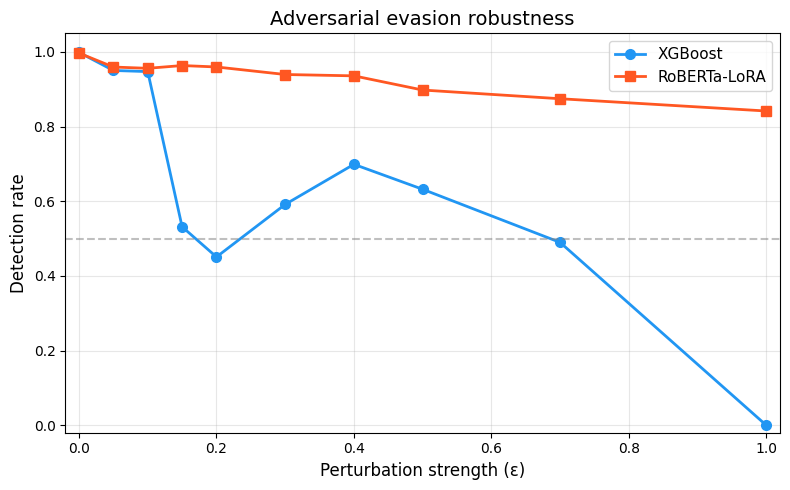

In [ ]:
# ============================================================
# BLOCK 7E — Evasion curve plot (for the paper)
# ============================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for mname, color, marker in [('XGBoost', '#2196F3', 'o'), ('RoBERTa-LoRA', '#FF5722', 's')]:
    sub = evasion_df[evasion_df.model==mname].sort_values('epsilon')
    ax.plot(sub['epsilon'], sub['detection_rate'],
            color=color, marker=marker, linewidth=2, markersize=7, label=mname)

ax.set_xlabel('Perturbation strength (ε)', fontsize=12)
ax.set_ylabel('Detection rate', fontsize=12)
ax.set_title('Adversarial evasion robustness', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig(f"{OUTPUT}/figures/evasion_curve.png", dpi=300, bbox_inches='tight')
print(f"Figure saved to {OUTPUT}/figures/evasion_curve.png")
plt.show()

---

## BLOCK 8 — Adversarial Robustness Testing [NOT YET STARTED]

**Timeline**: Aug 10-13

In [ ]:
# BLOCK 8 will go here
print("Block 8 placeholder")

Block 8 placeholder


---

## BLOCK 9 — Results & Figures [NOT YET STARTED]

**Timeline**: Aug 14-17

In [ ]:
import os
os.system('rm -rf /content/drive')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# BLOCK 9 — Paper figures & master results table
# Self-sufficient: reloads all results from Drive CSVs.
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

OUTPUT = '/content/drive/MyDrive/CybersecClassification/ids_output'
os.makedirs(f"{OUTPUT}/figures", exist_ok=True)

# Consistent styling across all figures (paper quality)
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

XGB_COLOR = '#1976D2'      # blue
LLM_COLOR = '#E64A19'      # orange-red
GREY = '#666666'

# ---- Load all raw results ----
rf_results   = pd.read_csv(f"{OUTPUT}/results/block4_harness_rf.csv")
xgb_results  = pd.read_csv(f"{OUTPUT}/results/block4_harness_xgb.csv")
llm_unsw     = pd.read_csv(f"{OUTPUT}/results/block5_roberta_unsw_full.csv")
llm_cic      = pd.read_csv(f"{OUTPUT}/results/block5_roberta_cic_full.csv")
evasion_df   = pd.read_csv(f"{OUTPUT}/results/block7_evasion_curve.csv")
ablation_df  = pd.read_csv(f"{OUTPUT}/results/block3_8_clean_ablation.csv")

# XGBoost means across seeds
xgb_mean = (xgb_results.groupby('condition')['f1'].mean().round(4).to_dict())
llm_all = pd.concat([llm_unsw, llm_cic], ignore_index=True)
llm_mean = dict(zip(llm_all['condition'], llm_all['f1']))

print("Loaded results:")
print(f"  XGBoost by condition: {xgb_mean}")
print(f"  RoBERTa by condition: {llm_mean}")

Loaded results:
  XGBoost by condition: {'CD_cic2unsw': 0.073, 'CD_unsw2cic': 0.8116, 'SD_cic': 0.9776, 'SD_unsw': 0.9966}
  RoBERTa by condition: {'SD_unsw': 0.9948, 'CD_unsw2cic': 0.6205, 'SD_cic': 0.9745, 'CD_cic2unsw': 0.0379}


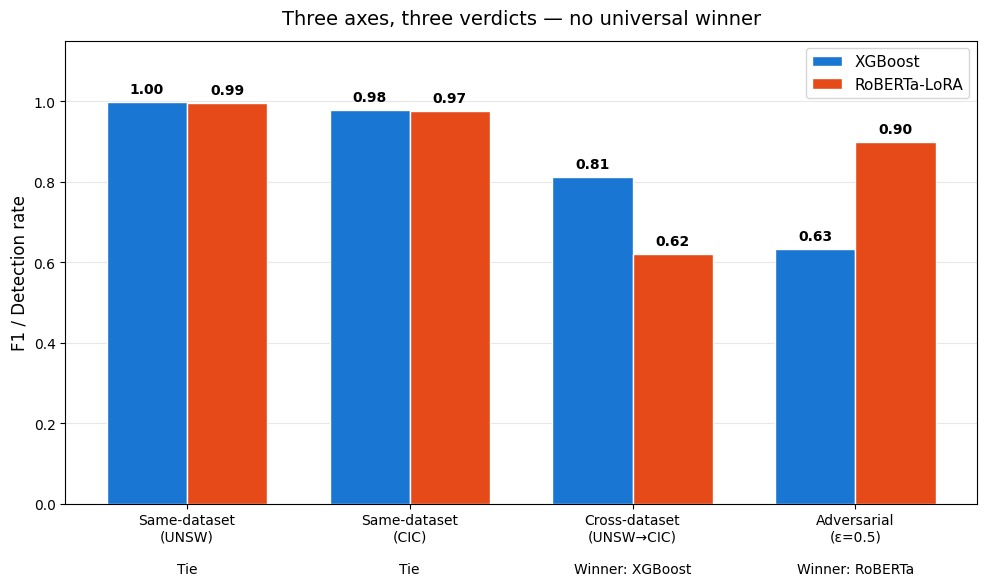

Saved: fig1_three_axis_summary.png


In [ ]:
# ============================================================
# FIGURE 1 — Three-axis summary (paper visual abstract)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

axes_labels = [
    'Same-dataset\n(UNSW)\n\nTie',
    'Same-dataset\n(CIC)\n\nTie',
    'Cross-dataset\n(UNSW→CIC)\n\nWinner: XGBoost',
    'Adversarial\n(ε=0.5)\n\nWinner: RoBERTa',
]

xgb_bars = [xgb_mean['SD_unsw'], xgb_mean['SD_cic'], xgb_mean['CD_unsw2cic'],
            evasion_df[(evasion_df.model=='XGBoost') & (evasion_df.epsilon==0.5)]['detection_rate'].values[0]]
llm_bars = [llm_mean['SD_unsw'], llm_mean['SD_cic'], llm_mean['CD_unsw2cic'],
            evasion_df[(evasion_df.model=='RoBERTa-LoRA') & (evasion_df.epsilon==0.5)]['detection_rate'].values[0]]

x = np.arange(len(axes_labels)); w = 0.36
b1 = ax.bar(x - w/2, xgb_bars, w, color=XGB_COLOR, label='XGBoost', edgecolor='white')
b2 = ax.bar(x + w/2, llm_bars, w, color=LLM_COLOR, label='RoBERTa-LoRA', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.015, f'{h:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(axes_labels, fontsize=10)
ax.set_ylabel('F1 / Detection rate')
ax.set_title('Three axes, three verdicts — no universal winner', fontsize=14, pad=12)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, axis='y', alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(f"{OUTPUT}/figures/fig1_three_axis_summary.png")
plt.show()
print("Saved: fig1_three_axis_summary.png")

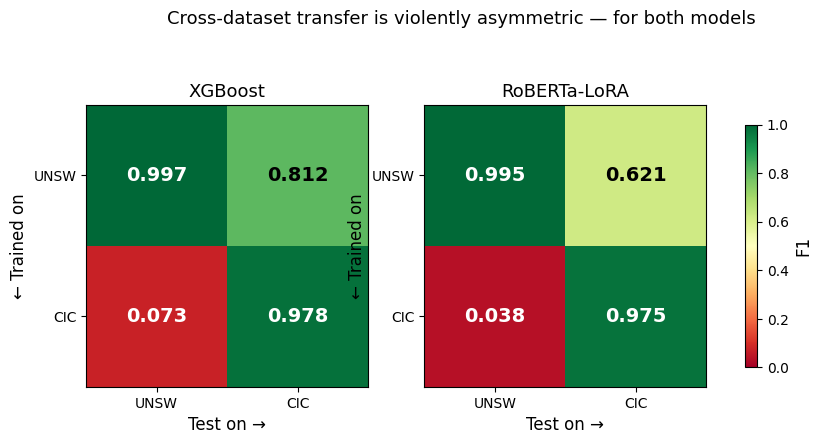

Saved: fig2_transfer_matrix.png


In [ ]:
# ============================================================
# FIGURE 2 — Cross-dataset asymmetry (2x2 heatmap per model)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

def transfer_matrix(xgb_get, llm_get):
    """Build the 2x2 [train_source][test_source] matrix."""
    return np.array([
        [xgb_get['SD_unsw'], xgb_get['CD_unsw2cic']],
        [xgb_get['CD_cic2unsw'], xgb_get['SD_cic']],
    ]), np.array([
        [llm_get['SD_unsw'], llm_get['CD_unsw2cic']],
        [llm_get['CD_cic2unsw'], llm_get['SD_cic']],
    ])

xgb_mat, llm_mat = transfer_matrix(xgb_mean, llm_mean)

for ax, mat, title in [(axes[0], xgb_mat, 'XGBoost'), (axes[1], llm_mat, 'RoBERTa-LoRA')]:
    im = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['UNSW', 'CIC'])
    ax.set_yticklabels(['UNSW', 'CIC'])
    ax.set_xlabel('Test on →')
    ax.set_ylabel('← Trained on')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            color = 'white' if mat[i,j] < 0.4 or mat[i,j] > 0.85 else 'black'
            ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center',
                    color=color, fontsize=14, fontweight='bold')

fig.colorbar(im, ax=axes, shrink=0.7, label='F1')
fig.suptitle('Cross-dataset transfer is violently asymmetric — for both models',
             y=1.02, fontsize=13)

fig.savefig(f"{OUTPUT}/figures/fig2_transfer_matrix.png")
plt.show()
print("Saved: fig2_transfer_matrix.png")

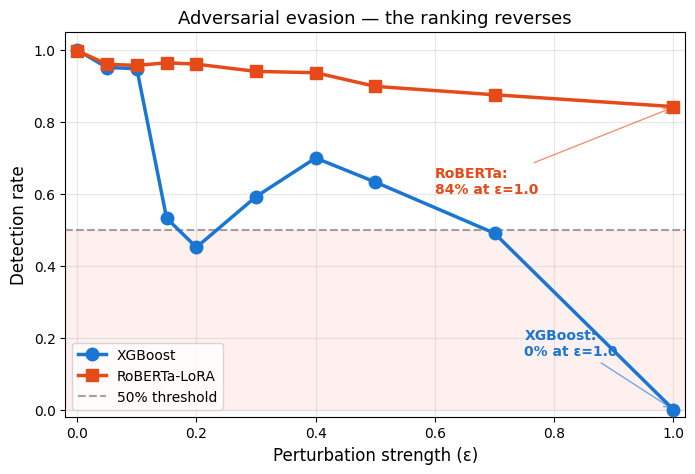

Saved: fig3_evasion_curve.png


In [ ]:
# ============================================================
# FIGURE 3 — Adversarial evasion robustness
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

for mname, color, marker in [('XGBoost', XGB_COLOR, 'o'), ('RoBERTa-LoRA', LLM_COLOR, 's')]:
    sub = evasion_df[evasion_df.model == mname].sort_values('epsilon')
    ax.plot(sub['epsilon'], sub['detection_rate'],
            color=color, marker=marker, linewidth=2.5, markersize=9,
            label=mname, zorder=3)

ax.axhline(y=0.5, color=GREY, linestyle='--', alpha=0.6, label='50% threshold', zorder=1)
ax.fill_between([-0.02, 1.02], 0, 0.5, color='red', alpha=0.06, zorder=0)

# Annotate the punchlines
ax.annotate('XGBoost:\n0% at ε=1.0', xy=(1.0, 0.0), xytext=(0.75, 0.15),
            fontsize=10, color=XGB_COLOR, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=XGB_COLOR, alpha=0.6))
ax.annotate('RoBERTa:\n84% at ε=1.0', xy=(1.0, 0.84), xytext=(0.60, 0.60),
            fontsize=10, color=LLM_COLOR, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=LLM_COLOR, alpha=0.6))

ax.set_xlabel('Perturbation strength (ε)')
ax.set_ylabel('Detection rate')
ax.set_title('Adversarial evasion — the ranking reverses')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3); ax.set_axisbelow(True)

fig.savefig(f"{OUTPUT}/figures/fig3_evasion_curve.png")
plt.show()
print("Saved: fig3_evasion_curve.png")

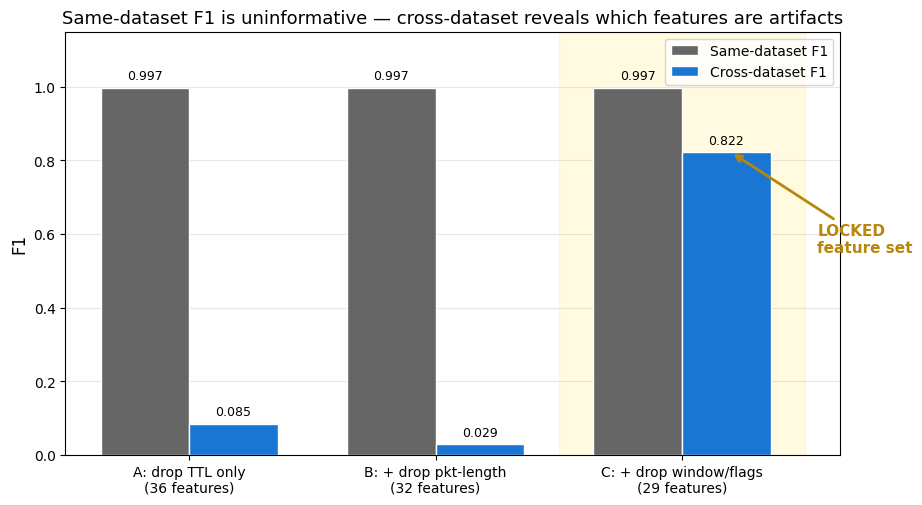

Saved: fig4_feature_ablation.png


In [ ]:
# ============================================================
# FIGURE 4 — Feature ablation (justifies feature set C)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

labels = ['A: drop TTL only\n(36 features)',
          'B: + drop pkt-length\n(32 features)',
          'C: + drop window/flags\n(29 features)']
sd_vals = ablation_df['SD_f1'].values
cd_vals = ablation_df['CD_f1'].values

x = np.arange(len(labels)); w = 0.36
b1 = ax.bar(x - w/2, sd_vals, w, color=GREY, label='Same-dataset F1', edgecolor='white')
b2 = ax.bar(x + w/2, cd_vals, w, color=XGB_COLOR, label='Cross-dataset F1', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.015, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('F1')
ax.set_title('Same-dataset F1 is uninformative — cross-dataset reveals which features are artifacts')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3); ax.set_axisbelow(True)

# Highlight set C with a subtle background
ax.axvspan(x[-1] - 0.5, x[-1] + 0.5, color='gold', alpha=0.12, zorder=0)

# Arrow pointing to set C from the right side
ax.annotate('LOCKED\nfeature set', xy=(x[-1] + 0.2, 0.822),
            xytext=(x[-1] + 0.55, 0.55),
            fontsize=11, fontweight='bold', color='darkgoldenrod',
            arrowprops=dict(arrowstyle='->', color='darkgoldenrod', lw=2),
            annotation_clip=False)

fig.savefig(f"{OUTPUT}/figures/fig4_feature_ablation.png")
plt.show()
print("Saved: fig4_feature_ablation.png")

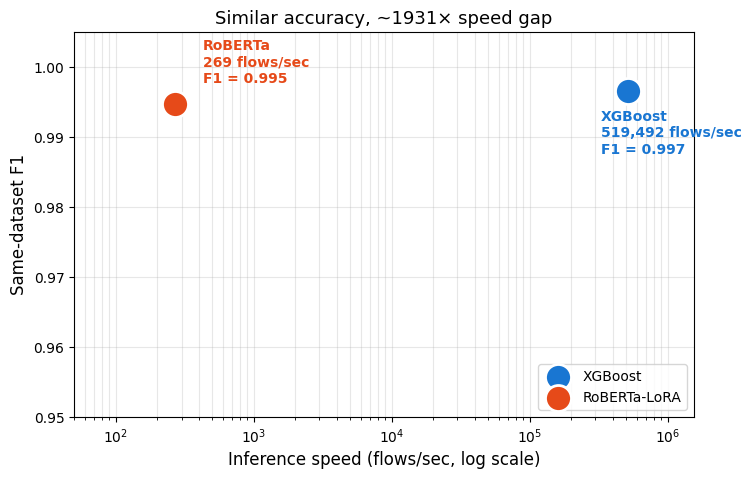

Saved: fig5_speed_accuracy.png


In [ ]:
# ============================================================
# FIGURE 5 — Speed vs accuracy tradeoff (Mehavilla-style)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

# XGBoost is deterministic across seeds for CD; grab a representative speed
xgb_speed = int(xgb_results[xgb_results.condition=='SD_unsw']['flows_sec'].mean())
llm_speed = int(llm_all[llm_all.condition=='SD_unsw']['flows_sec'].mean())

# Same-dataset accuracy (both close to ceiling)
xgb_acc = xgb_mean['SD_unsw']
llm_acc = llm_mean['SD_unsw']

ax.scatter([xgb_speed], [xgb_acc], s=350, color=XGB_COLOR, label='XGBoost',
           edgecolor='white', linewidth=2, zorder=3)
ax.scatter([llm_speed], [llm_acc], s=350, color=LLM_COLOR, label='RoBERTa-LoRA',
           edgecolor='white', linewidth=2, zorder=3)

ax.annotate(f'XGBoost\n{xgb_speed:,} flows/sec\nF1 = {xgb_acc:.3f}',
            xy=(xgb_speed, xgb_acc), xytext=(-20, -45),
            textcoords='offset points', fontsize=10, color=XGB_COLOR, fontweight='bold')
ax.annotate(f'RoBERTa\n{llm_speed:,} flows/sec\nF1 = {llm_acc:.3f}',
            xy=(llm_speed, llm_acc), xytext=(20, 15),
            textcoords='offset points', fontsize=10, color=LLM_COLOR, fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('Inference speed (flows/sec, log scale)')
ax.set_ylabel('Same-dataset F1')
ax.set_title(f'Similar accuracy, ~{xgb_speed // llm_speed}× speed gap')
ax.set_ylim(0.95, 1.005)
ax.set_xlim(50, xgb_speed*3)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, which='both'); ax.set_axisbelow(True)

fig.savefig(f"{OUTPUT}/figures/fig5_speed_accuracy.png")
plt.show()
print("Saved: fig5_speed_accuracy.png")

In [ ]:
# ============================================================
# MASTER TABLE — every result in one place, exportable to LaTeX
# ============================================================
rows = []

# Same-dataset and cross-dataset for both models
for cond, cond_label in [('SD_unsw', 'Same-dataset UNSW'),
                          ('SD_cic', 'Same-dataset CIC'),
                          ('CD_unsw2cic', 'Cross UNSW→CIC'),
                          ('CD_cic2unsw', 'Cross CIC→UNSW')]:
    rows.append({
        'Condition': cond_label,
        'XGBoost F1': f"{xgb_mean[cond]:.4f}",
        'RoBERTa F1': f"{llm_mean[cond]:.4f}",
        'Gap': f"{xgb_mean[cond] - llm_mean[cond]:+.4f}",
    })

# Adversarial at key epsilons
for eps in [0.0, 0.2, 0.5, 1.0]:
    x = evasion_df[(evasion_df.model=='XGBoost') & (evasion_df.epsilon==eps)]['detection_rate'].values[0]
    r = evasion_df[(evasion_df.model=='RoBERTa-LoRA') & (evasion_df.epsilon==eps)]['detection_rate'].values[0]
    rows.append({
        'Condition': f'Adversarial ε={eps}',
        'XGBoost F1': f"{x:.4f}",
        'RoBERTa F1': f"{r:.4f}",
        'Gap': f"{x - r:+.4f}",
    })

master = pd.DataFrame(rows)
master.to_csv(f"{OUTPUT}/results/master_results_table.csv", index=False)

print("\n" + "="*68)
print("MASTER RESULTS TABLE")
print("="*68)
print(master.to_string(index=False))
print("="*68)
print(f"\nSaved to {OUTPUT}/results/master_results_table.csv")
print("Also available as LaTeX with: master.to_latex(index=False)")


MASTER RESULTS TABLE
        Condition XGBoost F1 RoBERTa F1     Gap
Same-dataset UNSW     0.9966     0.9948 +0.0018
 Same-dataset CIC     0.9776     0.9745 +0.0031
   Cross UNSW→CIC     0.8116     0.6205 +0.1911
   Cross CIC→UNSW     0.0730     0.0379 +0.0351
Adversarial ε=0.0     0.9989     0.9971 +0.0018
Adversarial ε=0.2     0.4509     0.9599 -0.5090
Adversarial ε=0.5     0.6322     0.8981 -0.2659
Adversarial ε=1.0     0.0000     0.8419 -0.8419

Saved to /content/drive/MyDrive/CybersecClassification/ids_output/results/master_results_table.csv
Also available as LaTeX with: master.to_latex(index=False)


---

## BLOCK 10-13 — Writing [NOT YET STARTED]

**Timeline**: Aug 18-25

In [ ]:
# BLOCK 10-13 will be writing, not in this notebook
print("Writing phase starts Aug 18")

Writing phase starts Aug 18
